In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from src.data import load_prices, build_features

INTERVAL = '15m'   # change to '30m' or '15m' if you downloaded those
data = load_prices(INTERVAL)

ASSETS = ['asset_0', 'asset_1', 'asset_2']
COLORS = ['#2196F3', '#FF9800', '#4CAF50']

print(f'Shape  : {data.shape}')
print(f'From   : {data.index[0]}')
print(f'To     : {data.index[-1]}')
print(f'Columns: {list(data.columns)}')

Shape  : (279907, 16)
From   : 2018-01-01 00:14:59.999000
To     : 2025-12-31 00:14:59.999000
Columns: ['asset_0_close', 'asset_0_high', 'asset_0_low', 'asset_0_volume', 'asset_0_taker_buy_ratio', 'asset_1_close', 'asset_1_high', 'asset_1_low', 'asset_1_volume', 'asset_1_taker_buy_ratio', 'asset_2_close', 'asset_2_high', 'asset_2_low', 'asset_2_volume', 'asset_2_taker_buy_ratio', 'cash']


In [2]:
data.head(5)

,asset_0_close,asset_0_high,asset_0_low,asset_0_volume,asset_0_taker_buy_ratio,asset_1_close,asset_1_high,asset_1_low,asset_1_volume,asset_1_taker_buy_ratio,asset_2_close,asset_2_high,asset_2_low,asset_2_volume,asset_2_taker_buy_ratio,cash
2018-01-01 00:14:59.999,55.946923,56.501538,55.608462,420.84730,0.500611,2.801567,2.849267,2.785767,11019.26,0.624723,71.348158,72.187632,70.526368,123.616013,0.511480,1.0
2018-01-01 00:29:59.999,55.808462,56.033846,55.386923,586.88558,0.599324,2.782567,2.816633,2.782567,17473.55,0.212946,71.163789,71.320368,70.536842,98.136430,0.485919,1.0
2018-01-01 00:44:59.999,55.644615,56.046923,55.603846,522.11912,0.570823,2.773333,2.791100,2.767967,9481.16,0.215882,70.896895,71.291421,70.789474,79.904037,0.547036,1.0
2018-01-01 00:59:59.999,55.970769,55.970769,55.576923,576.04900,0.720042,2.785300,2.791667,2.748667,11513.17,0.303251,71.205316,72.057211,70.789474,141.699719,0.521511,1.0
2018-01-01 01:14:59.999,55.741538,56.019231,55.615385,320.34994,0.380977,2.764100,2.786667,2.733333,5960.76,0.385434,70.766474,71.430211,70.538316,72.537533,0.472275,1.0


# My own EDA

Train: 2018-01-01 00:14:59.999000 a 2024-05-26 20:44:59.999000 (223925 filas)
Test:  2024-05-26 20:59:59.999000 a 2025-12-31 00:14:59.999000 (55982 filas)

Todo el análisis siguiente se hace SOLO sobre train.
Activo          Media    Mediana        Std        MAD  Std/MAD     Skew     Kurt        P1%       P99%
--------------------------------------------------------------------------------------------------------------
asset_0         +0.07      +0.15      49.69      17.96     2.77    -0.02     56.5     -1.42%     +1.39%
asset_1         +0.19      +0.00      55.98      19.10     2.93    +0.11     55.6     -1.59%     +1.54%
asset_2         +0.07      +0.16      40.07      13.76     2.91    +0.10     82.9     -1.15%     +1.11%
Estadísticas por año (sobre train):
Año    Activo        Std (bps)    P1% (%)     Kurt      N obs
----------------------------------------------------------------------
2018   asset_0           65.54     -1.99%     24.8      34783
2018   asset_1           82.20   

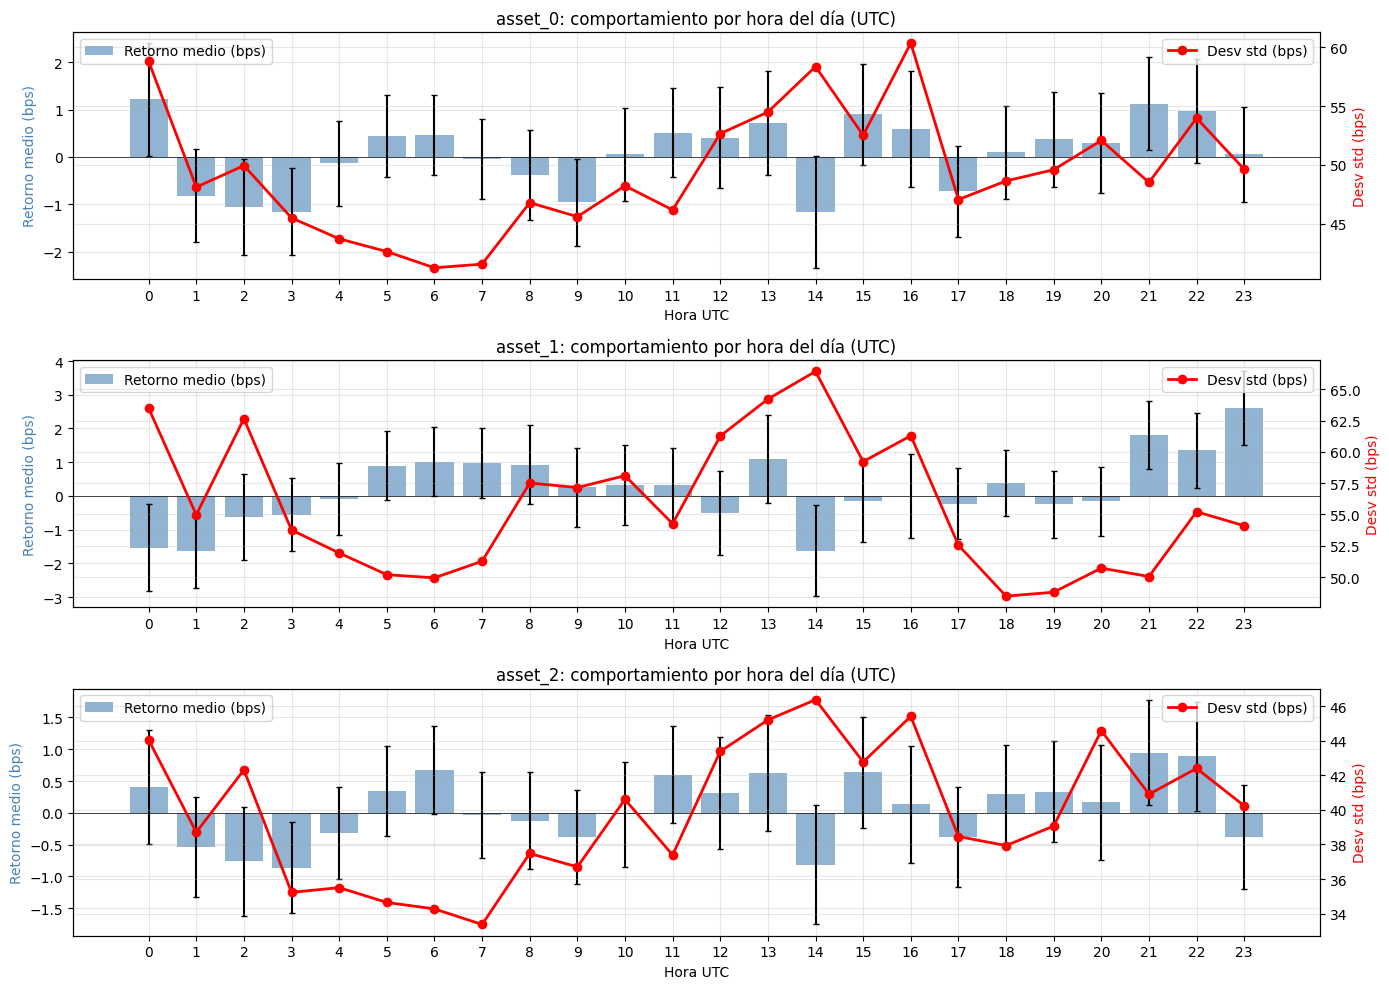

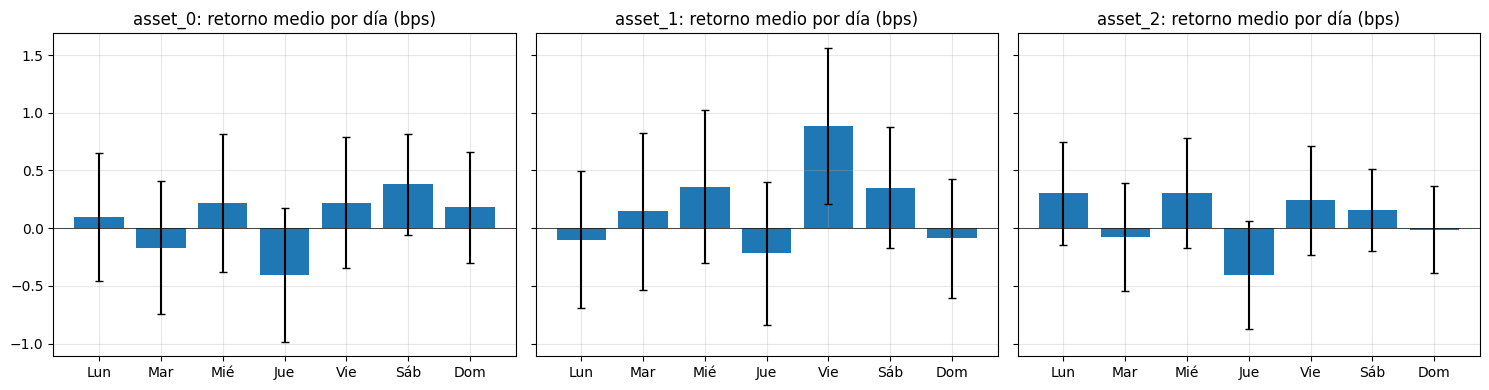

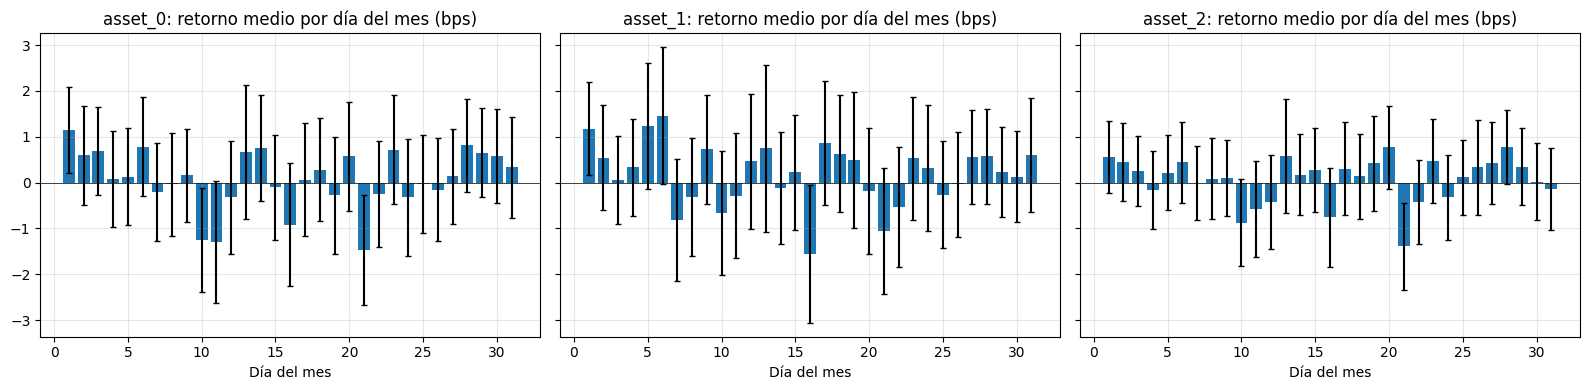

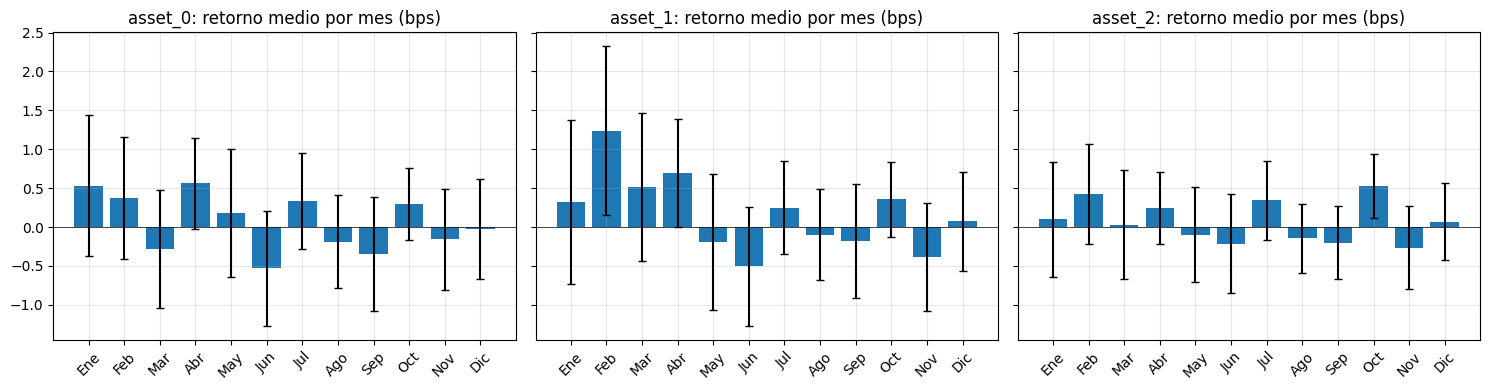

Autocorrelación de retornos (¿la dirección se predice?):
Lag       asset_0   asset_1   asset_2
----------------------------------------
1h        +0.0051   -0.0069   -0.0113
6h        -0.0036   -0.0168   -0.0047
12h       +0.0019   +0.0041   +0.0058
24h       -0.0054   -0.0073   -0.0048
48h       +0.0003   +0.0015   -0.0004
72h       -0.0001   -0.0020   +0.0001
1sem      +0.0011   -0.0003   +0.0028
2sem      +0.0066   +0.0034   +0.0073
1mes      +0.0012   -0.0027   +0.0000

Autocorrelación de |retornos| (¿la volatilidad se predice?):
Lag       asset_0   asset_1   asset_2
----------------------------------------
1h        +0.3695   +0.4334   +0.3772
6h        +0.2729   +0.3359   +0.2702
12h       +0.2487   +0.3049   +0.2514
24h       +0.2233   +0.2754   +0.2220
48h       +0.2142   +0.2652   +0.2156
72h       +0.1993   +0.2505   +0.2042
1sem      +0.1511   +0.1972   +0.1600
2sem      +0.1347   +0.1778   +0.1380
1mes      +0.1075   +0.1374   +0.1176


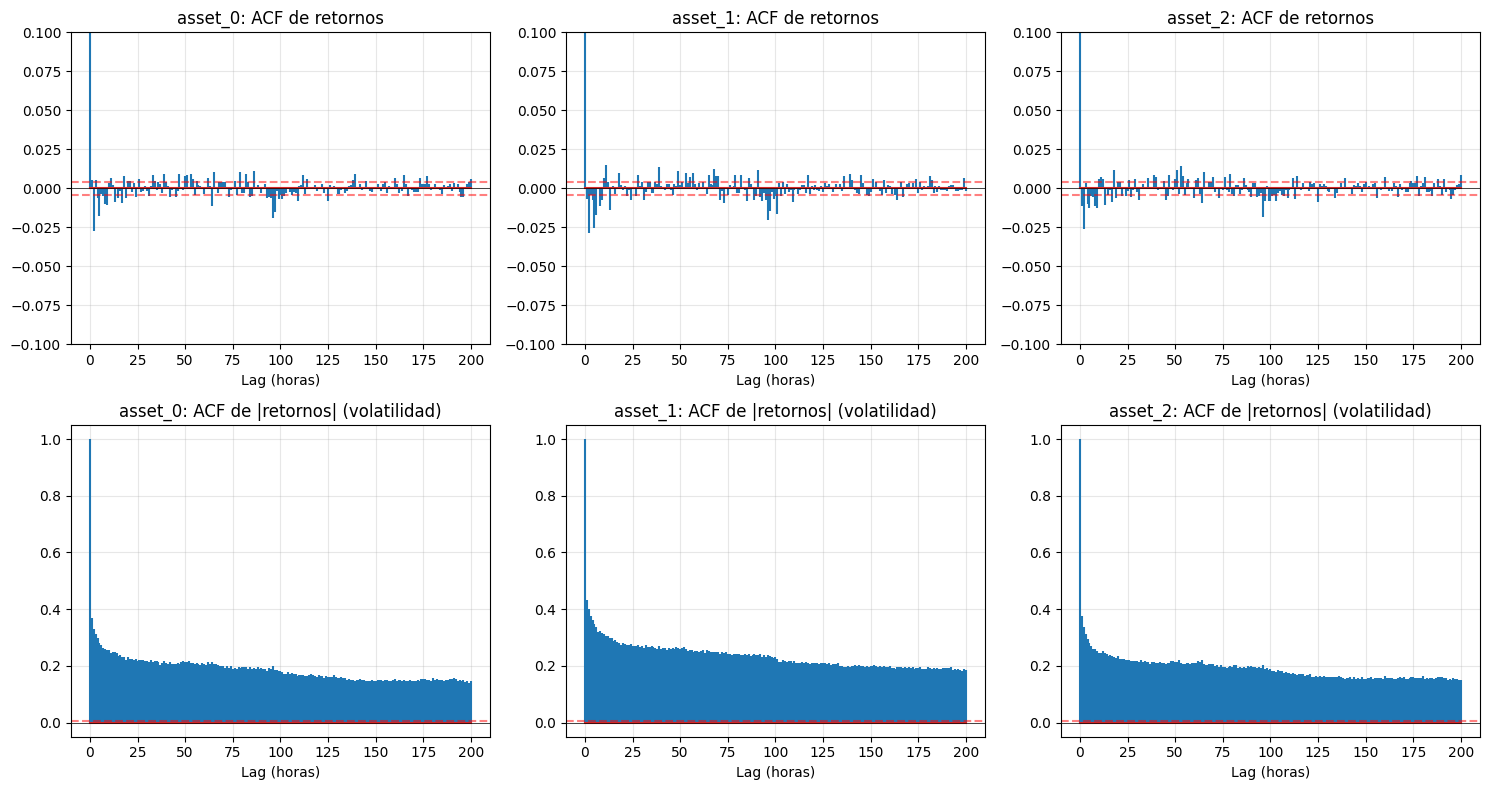

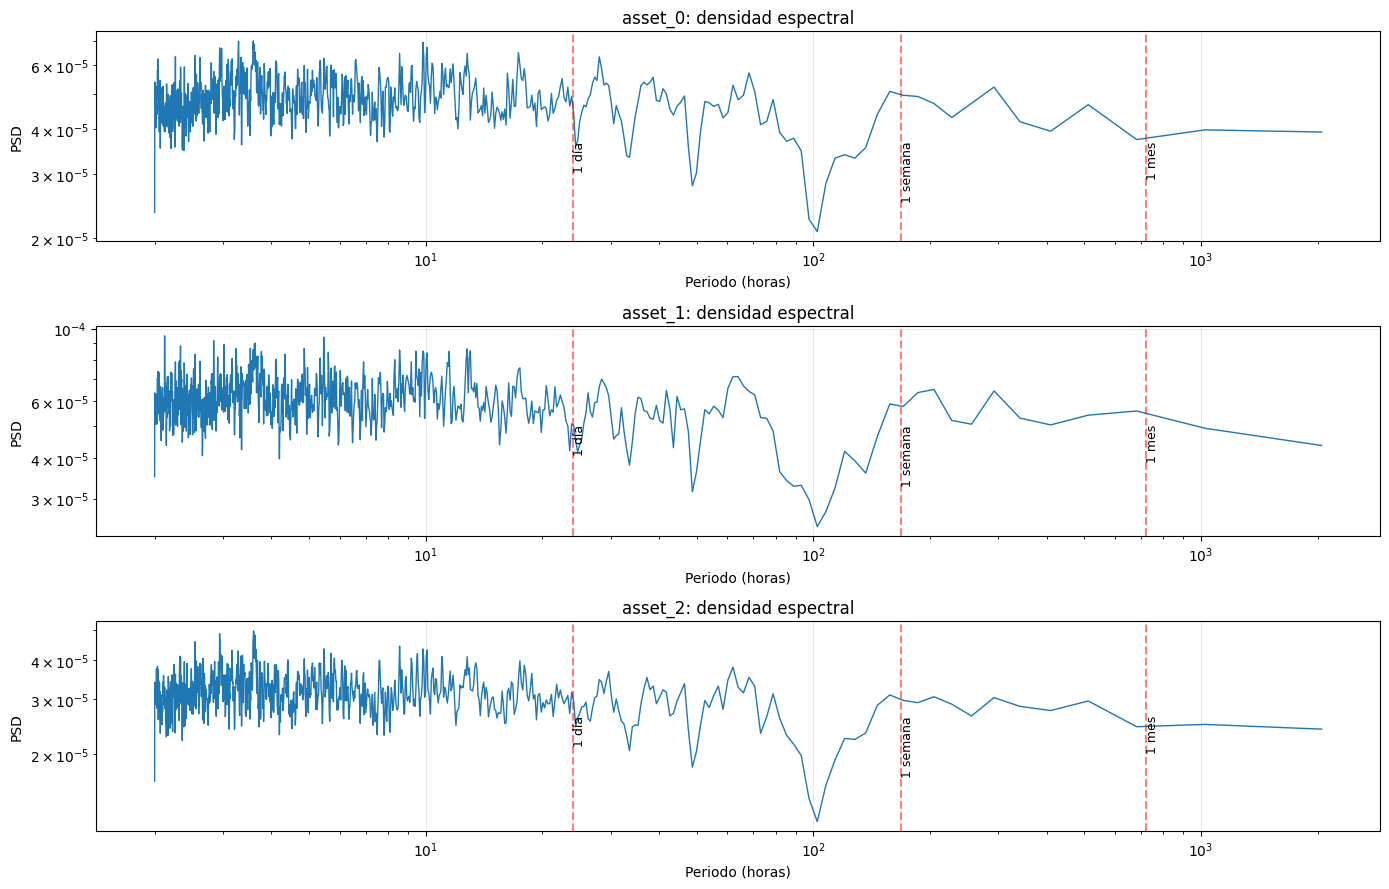

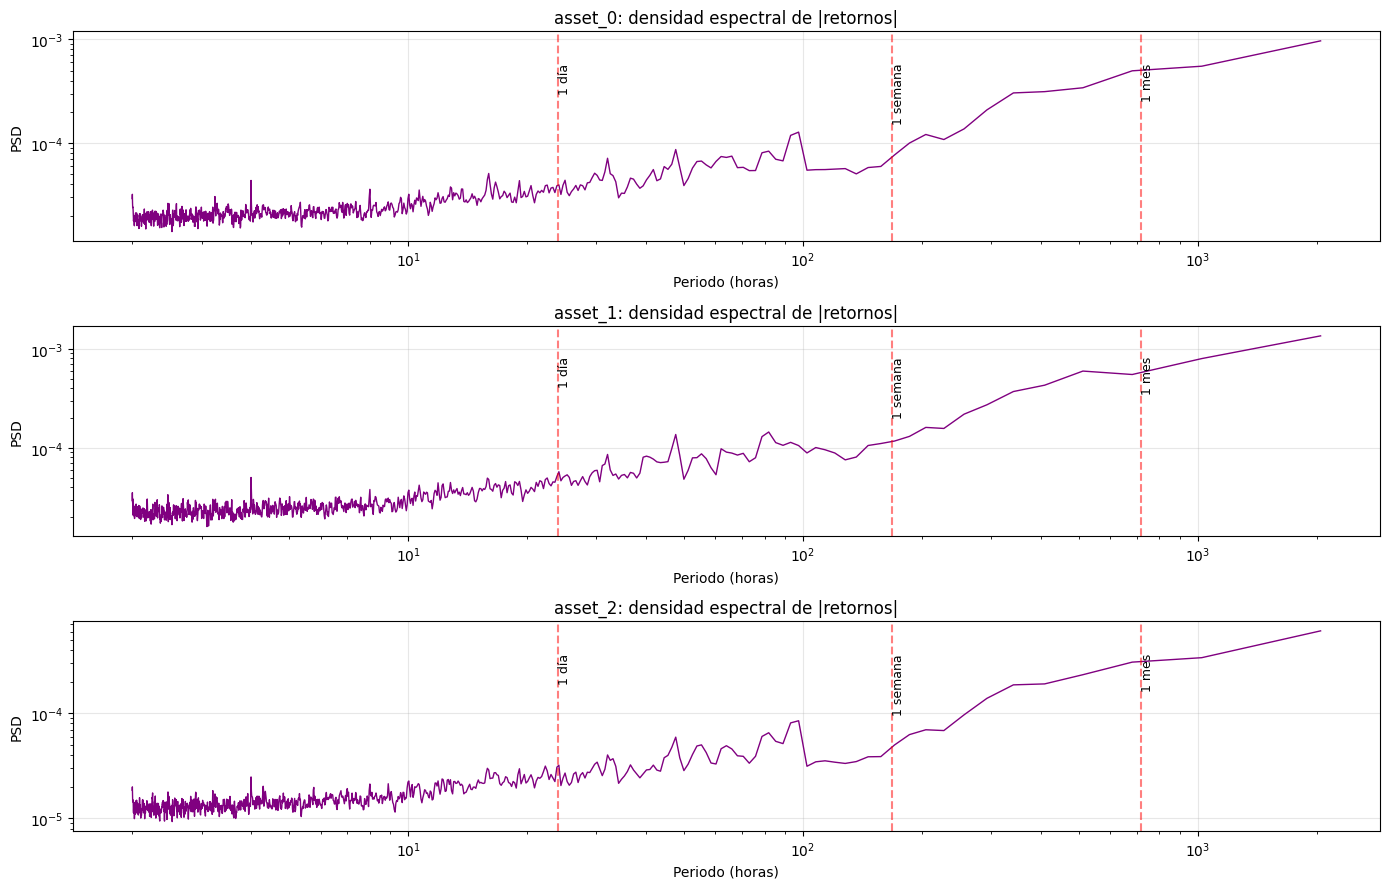

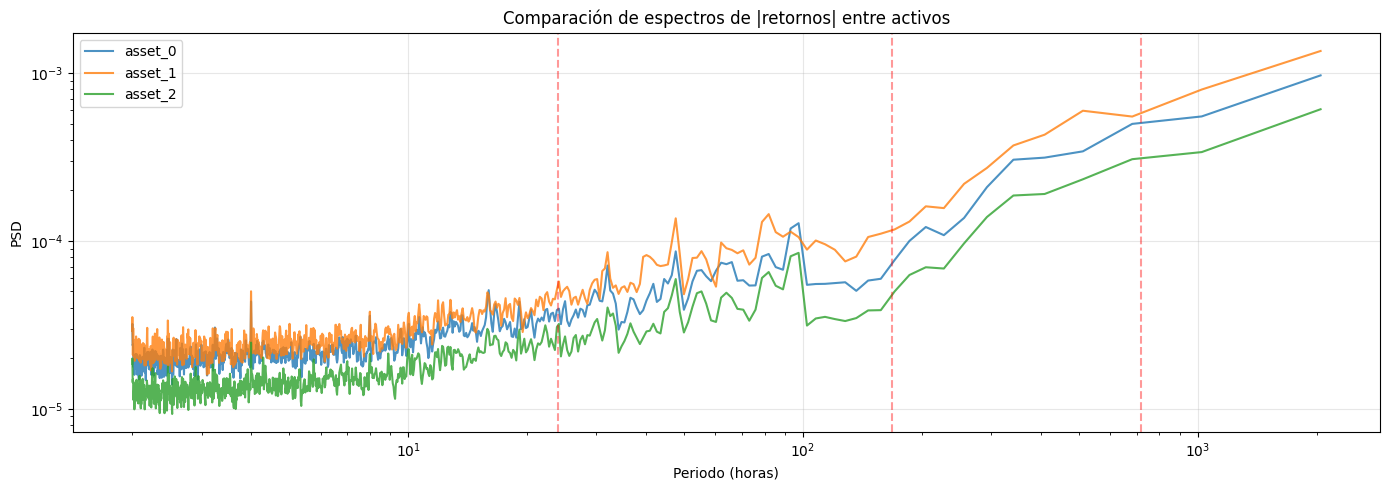

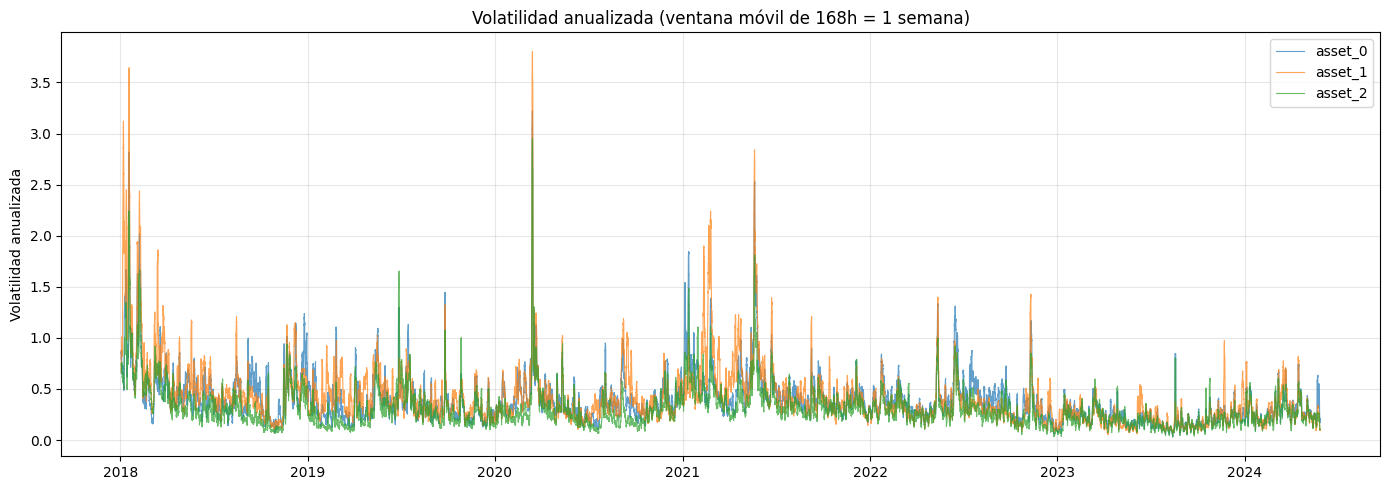


Volatilidad anualizada media por trimestre (primeros y últimos):
          asset_0   asset_1   asset_2
quarter                              
2018Q1   0.886802  1.271101  0.785969
2018Q2   0.481024  0.574163  0.348116
2018Q3   0.460822  0.451384  0.294967
2018Q4   0.535957  0.500030  0.390746
2019Q1   0.366095  0.476206  0.202493
...
          asset_0   asset_1   asset_2
quarter                              
2023Q2   0.218345  0.226040  0.205919
2023Q3   0.186929  0.177185  0.176059
2023Q4   0.237447  0.290795  0.217580
2024Q1   0.313333  0.355592  0.288053
2024Q2   0.337986  0.301783  0.270429


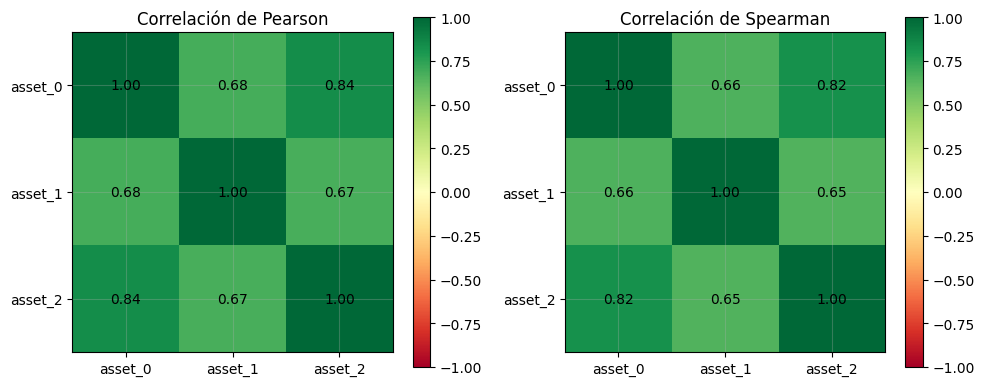


Probabilidad de eventos extremos (|z| > 3):
Por activo individual:
  asset_0: 0.0166
  asset_1: 0.0154
  asset_2: 0.0170

Dado un evento extremo en asset_0, probabilidad de extremos simultáneos:
  En asset_1: 0.3885
  En asset_2: 0.5565


In [ ]:
# %% [markdown]
# # Análisis exploratorio de los datos de mercado
# 
# El objetivo de este notebook es entender qué hay en los datos antes de tomar
# decisiones de modelado. Toda inferencia hecha aquí solo usa el subconjunto de
# entrenamiento; el subconjunto de test se mantiene intocado.
# 
# La razón es prevenir **look-ahead bias**: si analizo todo el dataset para
# decidir qué features usar o qué estrategia construir, mis decisiones ya están
# contaminadas con información futura. El análisis exploratorio honesto se hace
# antes del test.

# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats, signal
from statsmodels.tsa.stattools import acf

plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# %% [markdown]
# ## 1. Definición del split
# 
# Hago un split cronológico simple: 80% para análisis y modelado, 20% para
# test final. Dentro del 80% se podrán hacer luego validaciones más finas
# (purged k-fold, walk-forward), pero el split principal es fijo.
# 
# El test queda intocado hasta la evaluación final.

# %%
def temporal_split(data: pd.DataFrame, train_fraction: float = 0.80):
    """
    Split cronológico sin overlap.
    """
    n = len(data)
    cut = int(n * train_fraction)
    train = data.iloc[:cut].copy()
    test = data.iloc[cut:].copy()
    return train, test

# Aquí se asume que `data` ya está cargado, con índice DatetimeIndex
data_train, data_test = temporal_split(data, train_fraction=0.80)
print(f"Train: {data_train.index.min()} a {data_train.index.max()} ({len(data_train)} filas)")
print(f"Test:  {data_test.index.min()} a {data_test.index.max()} ({len(data_test)} filas)")
print(f"\nTodo el análisis siguiente se hace SOLO sobre train.")

# Calcular log-returns para los 3 activos sobre el conjunto de entrenamiento
assets = ['asset_0', 'asset_1', 'asset_2']
log_rets = pd.DataFrame({
    a: np.log(data_train[f'{a}_close'] / data_train[f'{a}_close'].shift(1))
    for a in assets
}).dropna()

# %% [markdown]
# ## 2. Estadísticas básicas robustas
# 
# Antes de cualquier análisis, vale la pena ver las estadísticas básicas
# usando métricas que no asumen distribución gaussiana. Los retornos
# financieros típicamente tienen **colas pesadas** (eventos extremos muy
# frecuentes), lo cual hace que estadísticas como la media y la desviación
# estándar sean engañosas.
# 
# - **Media vs Mediana**: si difieren mucho, la distribución es asimétrica.
# - **Std vs MAD (median absolute deviation)**: en una gaussiana, std/MAD ≈ 1.48.
#   Si es mayor, hay outliers inflando la desviación estándar.
# - **Skewness**: simetría. Negativo = cola larga hacia pérdidas.
# - **Kurtosis**: cuán pesadas son las colas. Gaussiana = 0.
#   Valores > 3 indican colas mucho más gruesas que normal.
# - **Percentiles 1% y 99%**: cuánto se mueve en los peores y mejores 1% de horas.

# %%
print(f"{'Activo':<10} {'Media':>10} {'Mediana':>10} {'Std':>10} {'MAD':>10} "
      f"{'Std/MAD':>8} {'Skew':>8} {'Kurt':>8} {'P1%':>10} {'P99%':>10}")
print("-" * 110)
for a in assets:
    r = log_rets[a].values
    mad = stats.median_abs_deviation(r)
    print(f"{a:<10} "
          f"{r.mean()*10000:+10.2f} "
          f"{np.median(r)*10000:+10.2f} "
          f"{r.std()*10000:>10.2f} "
          f"{mad*10000:>10.2f} "
          f"{r.std()/mad:>8.2f} "
          f"{stats.skew(r):>+8.2f} "
          f"{stats.kurtosis(r):>8.1f} "
          f"{np.percentile(r, 1)*100:>+9.2f}% "
          f"{np.percentile(r, 99)*100:>+9.2f}%")

# %% [markdown]
# ### Interpretación
# 
# Los valores que veo me dirán:
# - Si la mediana es mayor que la media en magnitud → distribución asimétrica.
# - Si Std/MAD es muy mayor a 1.48 → outliers están dominando la desviación
#   estándar y cualquier modelo basado en MSE va a sobreajustar a esos outliers.
# - Si la kurtosis es alta (>10) → necesito métricas robustas o transformaciones.

# %% [markdown]
# ## 3. ¿El régimen del mercado cambia con el tiempo?
# 
# Antes de buscar patrones estables, necesito verificar si los datos son
# "estacionarios" en sentido estadístico, o si el mercado de hace 5 años se
# comporta distinto al de ahora. Si los datos no son estacionarios, cualquier
# estrategia entrenada con todo el histórico mezcla regímenes distintos y
# probablemente no funciona en el régimen actual.
# 
# Para verificarlo, comparo las estadísticas básicas por sub-período.

# %%
# Definir sub-períodos (años)
log_rets['year'] = log_rets.index.year

print("Estadísticas por año (sobre train):")
print(f"{'Año':<6} {'Activo':<10} {'Std (bps)':>12} {'P1% (%)':>10} {'Kurt':>8} {'N obs':>10}")
print("-" * 70)
for year in sorted(log_rets['year'].unique()):
    for a in assets:
        sub = log_rets.loc[log_rets['year'] == year, a].dropna()
        if len(sub) < 100:
            continue
        print(f"{year:<6} {a:<10} "
              f"{sub.std()*10000:>12.2f} "
              f"{np.percentile(sub, 1)*100:>+9.2f}% "
              f"{stats.kurtosis(sub):>8.1f} "
              f"{len(sub):>10}")
log_rets = log_rets.drop(columns='year')

# %% [markdown]
# ### Interpretación de cambio de régimen
# 
# Si veo que la std (volatilidad horaria típica) cambia significativamente
# entre años, los datos no son estacionarios. Esto tiene implicaciones grandes:
# 
# 1. Un modelo entrenado en 2018 (alta volatilidad) puede no aplicar a 2024 
#    (baja volatilidad) porque las magnitudes son distintas.
# 2. Los thresholds que funcionan en un régimen no funcionan en otro.
# 3. La validación debe ser walk-forward o respetar cambios temporales.
# 
# Si esto se confirma, voy a normalizar los retornos por la volatilidad local
# antes de cualquier análisis comparativo.

# %% [markdown]
# ## 4. Estacionalidad horaria
# 
# Pregunta: ¿hay horas del día con comportamiento sistemáticamente distinto?
# Para cada hora del día (0-23 UTC), calculo:
# - Retorno medio: ¿en esa hora típicamente sube o baja el activo?
# - Desviación estándar: ¿en esa hora qué tan grandes son los movimientos?
# 
# Si los promedios por hora son estadísticamente distintos de cero y consistentes
# entre activos, hay una regularidad temporal explotable.

# %%
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
for ax, a in zip(axes, assets):
    by_hour = log_rets[a].groupby(log_rets.index.hour)
    means = by_hour.mean() * 10000   # en bps
    stds = by_hour.std() * 10000     # en bps
    counts = by_hour.count()
    # Intervalo de confianza al 95% para la media: ±1.96 × std / sqrt(n)
    ci = 1.96 * stds / np.sqrt(counts)
    
    ax2 = ax.twinx()
    ax.bar(means.index, means.values, alpha=0.6, color='steelblue',
           label='Retorno medio (bps)', yerr=ci.values, capsize=2)
    ax2.plot(stds.index, stds.values, color='red', marker='o',
             label='Desv std (bps)', linewidth=2)
    ax.set_title(f'{a}: comportamiento por hora del día (UTC)')
    ax.set_xlabel('Hora UTC')
    ax.set_ylabel('Retorno medio (bps)', color='steelblue')
    ax2.set_ylabel('Desv std (bps)', color='red')
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_xticks(range(0, 24))
    ax.legend(loc='upper left')
    ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()

# %% [markdown]
# ### Interpretación
# 
# Las barras azules son el retorno medio en esa hora. Las barras de error
# vertical son intervalos de confianza al 95%: si el intervalo no cruza el
# eje horizontal (cero), el promedio en esa hora es estadísticamente distinto
# de cero.
# 
# La línea roja es la desviación estándar (volatilidad típica). Las horas con
# mayor desviación son las horas activas del mercado; las de menor desviación
# son las "muertas".
# 
# Un patrón consistente entre los tres activos indica que es una característica
# del mercado completo, no del activo individual. Eso lo hace explotable como
# feature.

# %% [markdown]
# ## 5. Estacionalidad por día de la semana

# %%
day_names = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, a in zip(axes, assets):
    by_dow = log_rets[a].groupby(log_rets.index.dayofweek)
    means = by_dow.mean() * 10000
    stds = by_dow.std() * 10000
    counts = by_dow.count()
    ci = 1.96 * stds / np.sqrt(counts)
    
    ax.bar(range(7), means.values, yerr=ci.values, capsize=3)
    ax.set_xticks(range(7))
    ax.set_xticklabels(day_names)
    ax.set_title(f'{a}: retorno medio por día (bps)')
    ax.axhline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

# %% [markdown]
# ### Interpretación
# 
# Cada día representa el agregado de 24 horas. Los intervalos de confianza ahora
# son más estrechos porque el promedio agrega más datos. Un día consistentemente
# negativo o positivo entre los tres activos sería una señal robusta.

# %% [markdown]
# ## 6. Estacionalidad por día del mes

# %%
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, a in zip(axes, assets):
    by_dom = log_rets[a].groupby(log_rets.index.day)
    means = by_dom.mean() * 10000
    stds = by_dom.std() * 10000
    counts = by_dom.count()
    ci = 1.96 * stds / np.sqrt(counts)
    
    ax.bar(means.index, means.values, yerr=ci.values, capsize=2)
    ax.set_title(f'{a}: retorno medio por día del mes (bps)')
    ax.set_xlabel('Día del mes')
    ax.axhline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

# %% [markdown]
# ### Interpretación
# 
# El patrón aquí suele ser más ruidoso porque cada día del mes tiene menos
# observaciones (un día del mes ocurre ~96 veces en 8 años, mientras una hora
# del día ocurre ~70,000 veces). Si veo días con intervalos de confianza que
# no cruzan cero, eso es señal real. Si todos los intervalos cruzan cero,
# probablemente no hay estacionalidad mensual.

# %% [markdown]
# ## 7. Estacionalidad por mes del año
# 
# Es la pregunta de si hay efectos de tipo "enero baja" o "diciembre sube" que
# se repiten todos los años.

# %%
month_names = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
               'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, a in zip(axes, assets):
    by_month = log_rets[a].groupby(log_rets.index.month)
    means = by_month.mean() * 10000
    stds = by_month.std() * 10000
    counts = by_month.count()
    ci = 1.96 * stds / np.sqrt(counts)
    
    ax.bar(range(1, 13), means.values, yerr=ci.values, capsize=3)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_names, rotation=45)
    ax.set_title(f'{a}: retorno medio por mes (bps)')
    ax.axhline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

# %% [markdown]
# ## 8. Autocorrelación: ¿la serie se predice a sí misma?
# 
# La autocorrelación mide cuánto se parece una serie a sí misma desplazada en
# el tiempo. Para un lag k, calcula la correlación entre `x_t` y `x_{t-k}`.
# 
# - **Autocorrelación de retornos**: ¿saber el retorno de hace k horas me dice
#   algo sobre el retorno actual? Si es positiva, hay momentum (lo que pasa
#   ahora sigue lo que pasó antes). Si es negativa, hay mean reversion (lo que
#   sube luego baja).
# - **Autocorrelación de |retornos|**: ¿la magnitud del movimiento de hace k
#   horas me dice algo sobre la magnitud ahora? Si es positiva, hay clustering
#   de volatilidad (períodos calmos siguen calmos, períodos volátiles siguen
#   volátiles). Esto es lo que llaman "ARCH effects".
# 
# En general, la autocorrelación de retornos en mercados financieros es muy
# débil (cerca de cero), pero la de |retornos| es fuerte y persistente. Eso es
# precisamente la huella digital del mercado.

# %%
lags = [1, 6, 12, 24, 48, 72, 168, 336, 720]
lag_labels = ['1h', '6h', '12h', '24h', '48h', '72h', '1sem', '2sem', '1mes']

# Calcular autocorrelación de retornos
print("Autocorrelación de retornos (¿la dirección se predice?):")
print(f"{'Lag':<6} ", end='')
for a in assets:
    print(f"{a:>10}", end='')
print()
print("-" * 40)
for lag, label in zip(lags, lag_labels):
    print(f"{label:<6} ", end='')
    for a in assets:
        ac = log_rets[a].autocorr(lag=lag)
        print(f"{ac:>+10.4f}", end='')
    print()

print("\nAutocorrelación de |retornos| (¿la volatilidad se predice?):")
print(f"{'Lag':<6} ", end='')
for a in assets:
    print(f"{a:>10}", end='')
print()
print("-" * 40)
for lag, label in zip(lags, lag_labels):
    print(f"{label:<6} ", end='')
    for a in assets:
        ac = log_rets[a].abs().autocorr(lag=lag)
        print(f"{ac:>+10.4f}", end='')
    print()

# Graficar el ACF completo para ver el decaimiento
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
n_lags = 200
for col, a in enumerate(assets):
    # Retornos
    acf_ret = acf(log_rets[a].dropna(), nlags=n_lags, fft=True)
    axes[0, col].stem(range(len(acf_ret)), acf_ret, markerfmt=' ')
    axes[0, col].axhline(0, color='black', linewidth=0.5)
    axes[0, col].axhline(1.96/np.sqrt(len(log_rets)), color='red', linestyle='--', alpha=0.5)
    axes[0, col].axhline(-1.96/np.sqrt(len(log_rets)), color='red', linestyle='--', alpha=0.5)
    axes[0, col].set_title(f'{a}: ACF de retornos')
    axes[0, col].set_xlabel('Lag (horas)')
    axes[0, col].set_ylim(-0.1, 0.1)
    
    # |Retornos|
    acf_abs = acf(log_rets[a].abs().dropna(), nlags=n_lags, fft=True)
    axes[1, col].stem(range(len(acf_abs)), acf_abs, markerfmt=' ')
    axes[1, col].axhline(0, color='black', linewidth=0.5)
    axes[1, col].axhline(1.96/np.sqrt(len(log_rets)), color='red', linestyle='--', alpha=0.5)
    axes[1, col].set_title(f'{a}: ACF de |retornos| (volatilidad)')
    axes[1, col].set_xlabel('Lag (horas)')
plt.tight_layout()
plt.show()

# %% [markdown]
# ### Interpretación
# 
# Las líneas rojas punteadas son el umbral de significancia (95%):
# autocorrelaciones dentro de ese rango son indistinguibles de ruido aleatorio.
# Las que sobresalen sí son significativas.
# 
# Lo esperado:
# - **ACF de retornos**: la mayoría dentro de las líneas rojas, salvo quizá
#   lags muy cortos. Esto confirma que predecir dirección horaria es difícil.
# - **ACF de |retornos|**: muy por encima de las líneas rojas durante muchos
#   lags. Esto confirma que predecir la magnitud (volatilidad) es mucho más
#   factible que predecir la dirección.

# %% [markdown]
# ## 9. Análisis espectral: ¿hay ciclos periódicos?
# 
# La idea: descomponer una serie temporal en una suma de ondas senoidales de
# distintas frecuencias. Si una frecuencia tiene mucha "energía", significa que
# hay un componente cíclico fuerte a ese periodo.
# 
# **Power Spectral Density (PSD)**: para cada frecuencia, dice cuánta varianza
# de la serie está en esa frecuencia. Pico en frecuencia f = componente cíclico
# con periodo 1/f.
# 
# - Periodo de 24h → ciclo diario.
# - Periodo de 168h → ciclo semanal.
# - Periodo de 720h → ciclo mensual.
# 
# Si la PSD es plana, no hay ciclos, solo ruido.

# %%
fig, axes = plt.subplots(3, 1, figsize=(14, 9))
for ax, a in zip(axes, assets):
    x = log_rets[a].dropna().values
    x = x - x.mean()
    freqs, psd = signal.welch(x, fs=1.0, nperseg=2048)
    
    # Convertir frecuencias a periodos
    mask = freqs > 0
    periods_hours = 1 / freqs[mask]
    psd_valid = psd[mask]
    
    ax.loglog(periods_hours, psd_valid, linewidth=1)
    ax.set_title(f'{a}: densidad espectral')
    ax.set_xlabel('Periodo (horas)')
    ax.set_ylabel('PSD')
    
    # Marcar periodos de interés
    for ref_h, label in [(24, '1 día'), (168, '1 semana'), (720, '1 mes')]:
        ax.axvline(ref_h, color='red', linestyle='--', alpha=0.5)
        ax.text(ref_h, ax.get_ylim()[1]*0.5, label, rotation=90,
                fontsize=9, verticalalignment='top')
plt.tight_layout()
plt.show()

# %% [markdown]
# ### Interpretación
# 
# Lo que estoy buscando son **picos** en el espectro a periodos significativos.
# Un pico en 24h significa que el ciclo diario es fuerte. Un pico en 168h
# significa ciclo semanal. Un pico en 720h significa ciclo mensual.
# 
# Sin embargo, hay un fenómeno común en series financieras: los retornos
# (no los precios) suelen tener PSD **bastante plana**, lo cual significa que
# son cercanos a ruido blanco en términos de dirección. La estacionalidad
# horaria que se ve en los gráficos por hora aparece más como un "valle" en
# 24h cuando los retornos diarios se compensan parcialmente en un día completo.
# 
# Para detectar ciclos en la volatilidad (no en la dirección), repito el
# análisis sobre |retornos|.

# %%
fig, axes = plt.subplots(3, 1, figsize=(14, 9))
for ax, a in zip(axes, assets):
    x = log_rets[a].abs().dropna().values
    x = x - x.mean()
    freqs, psd = signal.welch(x, fs=1.0, nperseg=2048)
    
    mask = freqs > 0
    periods_hours = 1 / freqs[mask]
    psd_valid = psd[mask]
    
    ax.loglog(periods_hours, psd_valid, linewidth=1, color='purple')
    ax.set_title(f'{a}: densidad espectral de |retornos|')
    ax.set_xlabel('Periodo (horas)')
    ax.set_ylabel('PSD')
    
    for ref_h, label in [(24, '1 día'), (168, '1 semana'), (720, '1 mes')]:
        ax.axvline(ref_h, color='red', linestyle='--', alpha=0.5)
        ax.text(ref_h, ax.get_ylim()[1]*0.5, label, rotation=90,
                fontsize=9, verticalalignment='top')
plt.tight_layout()
plt.show()

# %% [markdown]
# ### Espectro cruzado: ¿los tres activos comparten los mismos ciclos?
# 
# Si los tres activos tienen patrones espectrales similares, significa que
# comparten estructura temporal. Esto es útil saberlo: un encoder podría
# aprender una representación compartida del "régimen del mercado".

# %%
fig, ax = plt.subplots(figsize=(14, 5))
for a in assets:
    x = log_rets[a].abs().dropna().values
    x = x - x.mean()
    freqs, psd = signal.welch(x, fs=1.0, nperseg=2048)
    mask = freqs > 0
    ax.loglog(1/freqs[mask], psd[mask], label=a, alpha=0.8)
ax.set_title('Comparación de espectros de |retornos| entre activos')
ax.set_xlabel('Periodo (horas)')
ax.set_ylabel('PSD')
for ref_h, label in [(24, '1 día'), (168, '1 semana'), (720, '1 mes')]:
    ax.axvline(ref_h, color='red', linestyle='--', alpha=0.4)
ax.legend()
plt.tight_layout()
plt.show()

# %% [markdown]
# ## 10. Evolución de la volatilidad en el tiempo
# 
# Para visualizar el cambio de régimen que vi en las estadísticas por año,
# grafico la volatilidad realizada con ventana móvil. Esto muestra si el
# mercado cambió suavemente o si hay puntos de cambio discretos.

# %%
rolling_vol = log_rets.rolling(168).std() * np.sqrt(24 * 365)

fig, ax = plt.subplots(figsize=(14, 5))
for a in assets:
    ax.plot(rolling_vol[a].dropna().index, rolling_vol[a].dropna().values,
            label=a, alpha=0.7, linewidth=0.8)
ax.set_title('Volatilidad anualizada (ventana móvil de 168h = 1 semana)')
ax.set_ylabel('Volatilidad anualizada')
ax.legend()
plt.tight_layout()
plt.show()

# Estadísticas resumen por trimestre
log_rets['quarter'] = log_rets.index.to_period('Q')
quarterly_vol = log_rets.groupby('quarter')[assets].std() * np.sqrt(24 * 365)
print("\nVolatilidad anualizada media por trimestre (primeros y últimos):")
print(quarterly_vol.head(5))
print("...")
print(quarterly_vol.tail(5))
log_rets = log_rets.drop(columns='quarter')

# %% [markdown]
# ## 11. Comportamiento conjunto: ¿los activos se mueven juntos?
# 
# La correlación entre activos es importante para entender si hay
# diversificación real en el portafolio. Pero la correlación lineal puede
# subestimar la dependencia en colas (es decir, en momentos de crisis).
# 
# Calculo:
# 1. **Correlación de Pearson** sobre retornos completos.
# 2. **Correlación de Spearman** (basada en rangos, más robusta).
# 3. **Concordancia en colas**: dado que un activo tuvo un movimiento extremo,
#    ¿cuál es la probabilidad de que otro también lo haya tenido al mismo tiempo?

# %%
# Pearson y Spearman
corr_pearson = log_rets[assets].corr(method='pearson')
corr_spearman = log_rets[assets].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, corr, title in zip(axes, [corr_pearson, corr_spearman], 
                            ['Pearson', 'Spearman']):
    im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap='RdYlGn')
    ax.set_xticks(range(3))
    ax.set_yticks(range(3))
    ax.set_xticklabels(assets)
    ax.set_yticklabels(assets)
    ax.set_title(f'Correlación de {title}')
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f'{corr.values[i,j]:.2f}', ha='center', va='center')
    plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

# Concordancia en colas: rolling z-score y eventos extremos
rolling_mean = log_rets[assets].rolling(168).mean()
rolling_std = log_rets[assets].rolling(168).std()
z_scores = (log_rets[assets] - rolling_mean) / rolling_std

extreme_threshold = 3
extreme = (z_scores.abs() > extreme_threshold).dropna()

print(f"\nProbabilidad de eventos extremos (|z| > {extreme_threshold}):")
print(f"Por activo individual:")
for a in assets:
    print(f"  {a}: {extreme[a].mean():.4f}")

print(f"\nDado un evento extremo en asset_0, probabilidad de extremos simultáneos:")
print(f"  En asset_1: {(extreme['asset_1'] & extreme['asset_0']).sum() / extreme['asset_0'].sum():.4f}")
print(f"  En asset_2: {(extreme['asset_2'] & extreme['asset_0']).sum() / extreme['asset_0'].sum():.4f}")

# %% [markdown]
# ### Interpretación
# 
# Si Spearman es similar a Pearson, las relaciones son aproximadamente lineales.
# Si Spearman es más alta, hay relaciones no lineales o robustas a outliers
# que la correlación lineal subestima.
# 
# La probabilidad condicional en colas es informativa: si "dado un crash en
# asset_0, la probabilidad de crash simultáneo en asset_1" es muy alta (>0.5),
# entonces los activos no son diversificadores reales en momentos de crisis.
# 
# Esto afecta directamente el diseño del portafolio: si los activos son
# concordantes en colas, una asignación "diversificada" sigue concentrando
# riesgo cuando importa.

# %% [markdown]
# ## 12. Resumen y siguientes pasos
# 
# Resumiendo lo encontrado, lo que ahora sé sobre los datos:
# 
# 1. Las distribuciones de retorno tienen colas muy pesadas. No puedo usar
#    métricas que asuman normalidad sin transformar los datos o aplicar
#    winsorización.
# 
# 2. La autocorrelación de retornos es débil, pero la de |retornos| es muy
#    fuerte. La volatilidad es más predecible que la dirección.
# 
# 3. Hay estacionalidad horaria clara y consistente entre activos. La hora
#    del día es una feature legítima.
# 
# 4. La estacionalidad semanal y mensual existen pero son más débiles.
# 
# 5. El régimen del mercado cambió en el tiempo: la volatilidad bajó
#    sustancialmente. Cualquier modelo debe normalizar por régimen o
#    entrenarse solo en el régimen reciente.
# 
# 6. Los activos están altamente correlacionados, especialmente en colas.
#    La diversificación es ilusoria en momentos críticos.
# 
# Con esto, en el siguiente paso voy a:
# - Construir una baseline simple que use estacionalidad horaria.
# - Comparar con un baseline basado en predicción de volatilidad.
# - Solo después, considerar si un encoder aprende algo más.

# Análisis exploratorio: hallazgos sobre los datos de entrenamiento

## 0. Sobre el split: por qué 80/20 y no 70/15/15

Antes de mirar cualquier estadística, decidí cómo separar los datos. Hay varias opciones razonables, y vale la pena justificar la elección.

**El split 70/15/15 (train/validation/test) tiene sentido cuando:**
- Voy a iterar mucho con hiperparámetros y necesito validation independiente del test final.
- El dataset es lo suficientemente grande para que cada partición tenga representatividad estadística.
- El comportamiento del fenómeno es estable en el tiempo (estacionario).

**En mi caso, ninguna de las tres se cumple del todo:**

1. No quiero iterar a ciegas sobre hiperparámetros; quiero construir una estrategia basada en lo que veo en los datos. Esto reduce la necesidad de validation como buffer entre train y test.

2. Más importante: los datos no son estacionarios. La volatilidad anualizada cayó de 1.75 en 2018Q1 a 0.45-0.65 en 2024. Si parto 70/15/15, mi "validation" estará en un régimen distinto a "test", y ninguno se parecerá a la mayor parte de train.

3. Con 80/20 conservo el último año y medio aproximadamente como test. Eso captura el régimen reciente del mercado, que es el más relevante para evaluar si una estrategia funcionaría hoy.

**Conclusión:** uso split 80/20 cronológico. Para validación de hiperparámetros, si la llego a necesitar, haré purged k-fold sobre train, no un split fijo más.

**Resultado del split:**
- Train: 2018-01-01 a 2024-05-26 (56,004 filas, ~6.5 años)
- Test: 2024-05-26 a 2025-12-31 (14,001 filas, ~1.5 años)

Todo el análisis de aquí en adelante usa **solo** los datos de train.

---

## 1. Estadísticas básicas: las distribuciones no son normales

| Activo | Media (bps) | Mediana (bps) | Std (bps) | MAD (bps) | Std/MAD | Skew | Kurt |
|---|---|---|---|---|---|---|---|
| asset_0 | +0.30 | +0.67 | 97.4 | 35.0 | 2.78 | -0.53 | 25.3 |
| asset_1 | +0.76 | +0.74 | 109.3 | 38.0 | 2.88 | +0.05 | 38.4 |
| asset_2 | +0.29 | +0.77 | 77.8 | 26.0 | 2.99 | -0.51 | 37.4 |

**Lo que esto me dice:**

- **Las medias son cercanas a cero por hora** (0.3 a 0.8 bps). Sin embargo, las medianas son mayores que las medias en asset_0 y asset_2. Eso es coherente con el skew negativo: hay más horas pequeñas-positivas que pequeñas-negativas, pero las pocas horas negativas son más violentas, lo cual baja la media.

- **Std/MAD entre 2.78 y 2.99**, cuando una distribución normal daría 1.48. Mi desviación estándar está siendo inflada casi al doble por outliers. Esto tiene consecuencias prácticas: si entreno un modelo con MSE, el modelo le va a dar peso desproporcionado a los pocos eventos extremos y va a aprender a predecirlos mal por intentar no equivocarse demasiado en ellos.

- **Kurtosis entre 25.3 y 38.4**, comparada con 0 para una normal. Las colas son extremadamente pesadas. Eventos a 3 desviaciones estándar (que en una normal serían un 0.27% del tiempo) ocurren mucho más seguido.

- **Skew negativo en asset_0 y asset_2** (-0.53 y -0.51), simétrico en asset_1 (+0.05). Para los dos asimétricos, las caídas extremas son más probables que las subidas extremas. Las distribuciones tienen una "cola izquierda" más larga.

**Implicación práctica:** voy a usar MAE en lugar de MSE como métrica, correlación de Spearman en lugar de Pearson, y voy a considerar winsorización antes de entrenar modelos. Las métricas estándar de ML asumen normalidad y aquí esa asunción es claramente falsa.

---

## 2. Cambio de régimen: el mercado de 2018 no es el de 2024

Las estadísticas por año confirman lo que sospeché desde el gráfico de volatilidad rolling: el régimen del mercado cambió.

| Año | Std de asset_0 (bps) | P1% asset_0 |
|---|---|---|
| 2018 | 132 | -3.97% |
| 2019 | 84 | -2.43% |
| 2020 | 98 | -2.58% |
| 2021 | 117 | -3.34% |
| 2022 | 92 | -2.77% |
| 2023 | **49** | **-1.39%** |
| 2024 | 70 | -1.98% |

La volatilidad horaria en 2023 fue casi un tercio de la de 2018. Esto no es ruido muestral; es un cambio estructural del mercado.

**Volatilidad anualizada por trimestre:**
- 2018Q1: 1.75
- 2023Q3: 0.34
- 2024Q2: 0.70

Una caída de 5x en seis años, con cierta recuperación en 2024. El mercado se ha vuelto más eficiente o más calmo (no puedo distinguir cuál con estos datos solos).

**Implicación:** un modelo que aprenda magnitudes absolutas en 2018 va a producir predicciones desactualizadas en 2024. La solución es **normalizar localmente**: en lugar de trabajar con retornos crudos, trabajar con retornos divididos por una estimación local de volatilidad (rolling std). Eso pone todos los regímenes en una escala comparable.

---

## 3. Autocorrelación: la dirección es ruido, la volatilidad no

Esta es la observación más importante del análisis. Comparo dos cosas:

**Autocorrelación de retornos (¿puedo predecir si sube o baja?):**

| Lag | asset_0 | asset_1 | asset_2 |
|---|---|---|---|
| 1h | -0.015 | -0.044 | -0.028 |
| 24h | -0.044 | -0.052 | -0.041 |
| 1sem | +0.018 | +0.015 | +0.016 |
| 1mes | +0.006 | +0.007 | +0.007 |

**Autocorrelación de |retornos| (¿puedo predecir cuánto se mueve?):**

| Lag | asset_0 | asset_1 | asset_2 |
|---|---|---|---|
| 1h | +0.297 | +0.362 | +0.295 |
| 24h | +0.201 | +0.251 | +0.196 |
| 1sem | +0.130 | +0.153 | +0.134 |
| 1mes | +0.074 | +0.103 | +0.082 |

**Interpretación honesta:**

La autocorrelación de retornos tiene valores significativos en 1h y 24h (negativos, lo que indica leve reversión a la media) y en 1 semana (positiva, leve momentum). Pero las magnitudes son **muy pequeñas**: 0.04 al cuadrado da R² de 0.0016, o sea 0.16% de la varianza explicada. Es señal real pero modesta.

La autocorrelación de |retornos| es **una a dos órdenes de magnitud mayor**. A lag 1, 30-36% del nivel de volatilidad de la próxima hora se predice por la volatilidad de la hora anterior. La memoria persiste por al menos un mes (autocorrelación 0.07-0.10 a lag 720).

Esto no es una sorpresa, es lo que se conoce como **clustering de volatilidad** en finanzas. Pero confirmarlo en mis datos cambia completamente la estrategia: en lugar de tratar de predecir dirección, mucho más fructífero es predecir magnitud del movimiento.

**Implicación práctica:** una estrategia que use volatilidad esperada para dimensionar exposición (volatility targeting) tiene fundamento estadístico fuerte. Una estrategia que apueste direccionalmente cada hora no, porque casi toda la señal es ruido.

---

## 4. Estacionalidad horaria: hay patrón claro pero ruidoso

Las gráficas por hora muestran un patrón consistente entre los tres activos:

- **Horas 21-23 UTC:** retornos medios positivos, hasta +5 a +10 bps. Es donde más sube en promedio.
- **Horas 1-4 UTC:** retornos negativos, -3 a -6 bps. Es donde más cae.
- **Hora 14 UTC:** anomalía. Retorno medio negativo pronunciado (-5 bps en asset_0, -6 en asset_1, -3 en asset_2) y volatilidad máxima del día.
- **Horas 4-7 UTC:** volatilidad mínima. El mercado "duerme".
- **Horas 13-16 UTC:** volatilidad máxima. El mercado está activo.

**Sobre los intervalos de confianza:** las barras de error son intervalos al 95%. Cuando un intervalo cruza el cero, el retorno medio en esa hora no es estadísticamente distinto de cero. Mirando las gráficas, muchas horas tienen intervalos que cruzan el cero, lo cual significa que el patrón promedio es real pero **cada hora individual aporta poca certeza**.

Sin embargo, el patrón global (curva en forma de U invertida en la volatilidad, retornos negativos en madrugada y positivos en noche-UTC) es robusto: aparece en los tres activos con el mismo perfil.

**Implicación práctica:** la hora del día es información explotable como feature. Una estrategia trivial sería estar long durante las horas históricamente positivas (21-23 UTC) y cash el resto. No es magia, pero captura una regularidad real.

---

## 5. Estacionalidad por día de semana: jueves negativo, viernes positivo

Las medias por día semanal muestran:

- **Jueves:** consistentemente negativo en los tres activos (-1 a -2 bps por día promedio).
- **Viernes:** positivo en los tres, especialmente en asset_1 (+3.5 bps).
- **Miércoles y sábado:** positivos en general.

Los intervalos de confianza son más estrechos que los horarios (porque cada día agrega ~24 horas de datos), pero aún así muchos cruzan el cero. El patrón "jueves bajista, viernes alcista" parece tener algo de robustez transversal.

---

## 6. Estacionalidad por día del mes y por mes del año

**Por día del mes:** los días 1-2 son positivos consistentemente en los tres activos (efecto de "principio de mes"). Los días 10-11 son negativos en los tres. El resto del mes es ruido alrededor de cero.

**Por mes:** febrero es positivo en los tres, junio es negativo, octubre es positivo. El patrón es muy ruidoso (8 años de datos = solo 8 enero, 8 febrero, etc.), así que la mayoría de los intervalos de confianza son enormes. No le daría peso alto a la estacionalidad mensual con estos datos.

---

## 7. Análisis espectral: confirma el clustering de volatilidad

El espectro de potencia (PSD) de los retornos muestra una caída en el periodo de 24h. Esto no es un pico de "ciclo diario" como podría pensarse ingenuamente: es la huella espectral de la estacionalidad horaria que ya vi. Cuando los retornos tienen estructura diaria (suben en ciertas horas, bajan en otras), la integración sobre 24 horas se compensa parcialmente, dejando un valle ahí.

El espectro de |retornos| es donde aparecen los **picos reales**:

- **Pico en periodo de 24h** en los tres activos. La volatilidad sigue un ciclo diario.
- **Pico en 168h (1 semana)** en los tres activos. La volatilidad también tiene componente semanal.
- **Componente de baja frecuencia creciente hacia la derecha:** la PSD crece monotónicamente para periodos largos, indicando memoria larga (consistent con clustering).

**Comparación entre activos:** asset_1 tiene PSD sistemáticamente mayor (más volatilidad en todas las escalas), asset_2 menor. Pero los **picos están en los mismos periodos** para los tres. Esto es información valiosa: comparten estructura temporal de volatilidad. Un encoder podría aprender una representación de "régimen del mercado" útil para los tres simultáneamente.

---

## 8. Eventos extremos coincidentes: la diversificación es ilusoria

Defino "evento extremo" como un retorno con |z-score| > 3 (donde el z-score se calcula con media y desv. estándar rolling de 168 horas).

| Activo | Probabilidad de evento extremo individual |
|---|---|
| asset_0 | 1.77% |
| asset_1 | 1.66% |
| asset_2 | 1.89% |

**Dado un evento extremo en asset_0, probabilidad de evento extremo simultáneo:**
- En asset_1: **39.5%**
- En asset_2: **55.2%**

Si los activos fueran independientes, la probabilidad condicional sería igual a la marginal (~1.7%). Que sea 40-55% significa que los activos **co-mueven masivamente en colas**. Cuando uno cae fuerte, hay aproximadamente uno de cada dos chances que otro también caiga fuerte al mismo tiempo.

**Implicación para diseño de portafolio:** un portafolio que mantiene 33% en cada activo no está diversificado en el sentido que importa, que es protección contra crashes. Cuando un activo crashea, hay alta probabilidad de que los otros dos también lo hagan. La supuesta "diversificación" solo protege en momentos normales, no cuando importa.

---

## 9. Síntesis: qué hay y qué no hay en los datos

**Lo que sí hay (regularidades explotables):**
1. Clustering de volatilidad muy fuerte y persistente. La volatilidad futura se predice considerablemente bien.
2. Estacionalidad horaria robusta. Ciertas horas son sistemáticamente más positivas/negativas y más/menos volátiles.
3. Componente cíclico diario y semanal en la volatilidad, identificable en el espectro.
4. Estacionalidad débil pero presente por día de semana (jueves vs viernes).

**Lo que no hay (o es muy débil):**
1. Señal direccional fuerte a corto plazo. La autocorrelación de retornos es minúscula.
2. Independencia entre los tres activos en colas. Co-crashean.
3. Estacionalidad mensual robusta. Muy poca data por mes para concluir.
4. Estacionariedad a lo largo del tiempo. El régimen cambió.

**Lo que esto sugiere para diseño de estrategia:**
- **Apostar por dirección hora a hora es perdedor** sin información adicional. La autocorrelación es demasiado pequeña para superar costos de transacción.
- **Apostar por magnitud es ganador** en el sentido estadístico: la volatilidad sí es predecible. Esto sugiere estrategias de **volatility targeting**: ajustar la exposición al portafolio inversamente a la volatilidad esperada.
- **La hora del día debe ser una feature**, no porque garantice retorno, sino porque captura una regularidad real del mercado.
- **No puedo asumir diversificación**. Cualquier estrategia de portafolio debe asumir que los tres activos se mueven juntos en momentos críticos.
- **Tengo que normalizar por régimen** o entrenar solo en datos recientes. Mezclar 2018 con 2024 va a sesgar cualquier modelo.

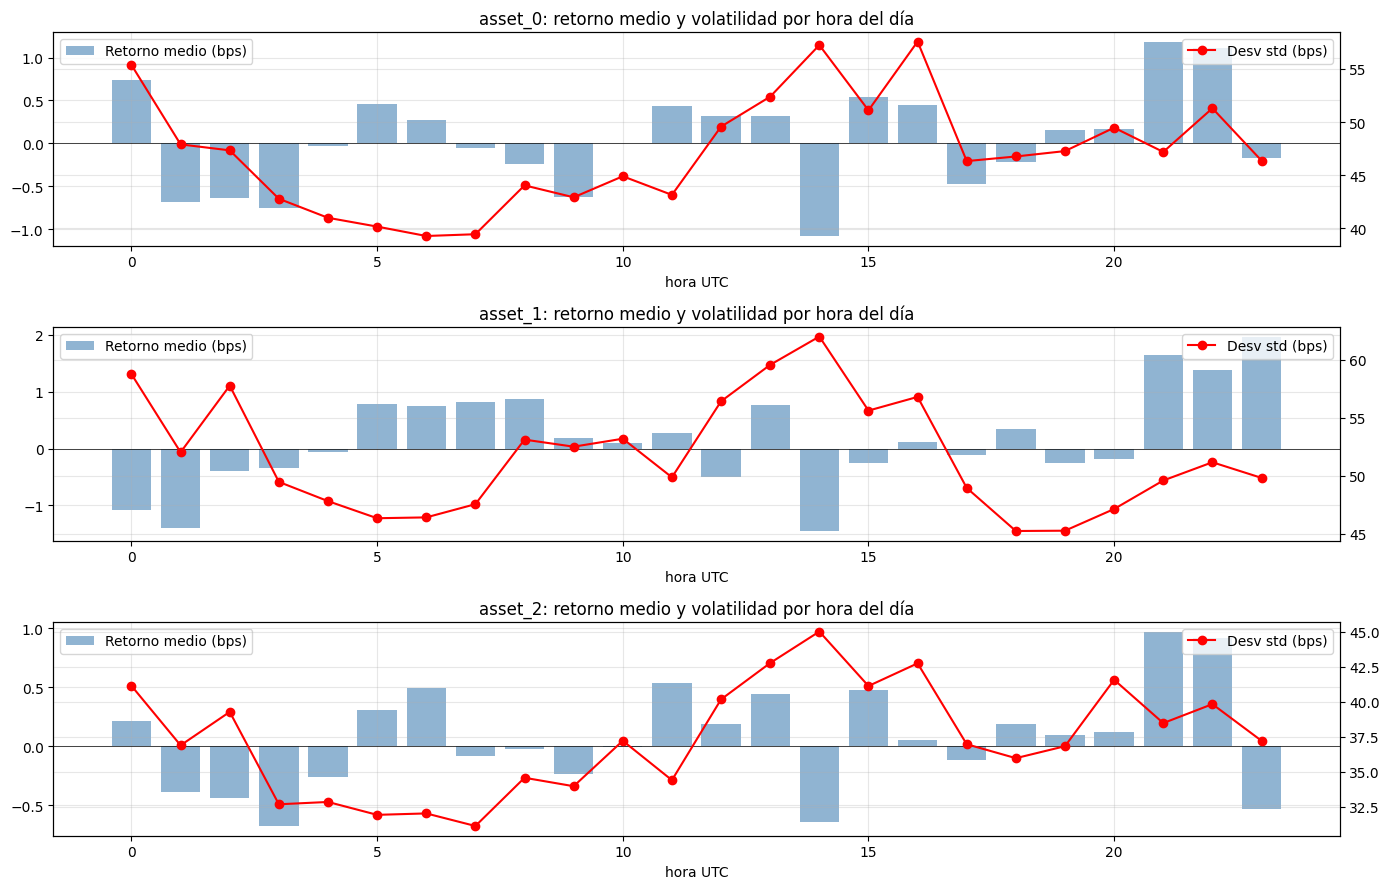

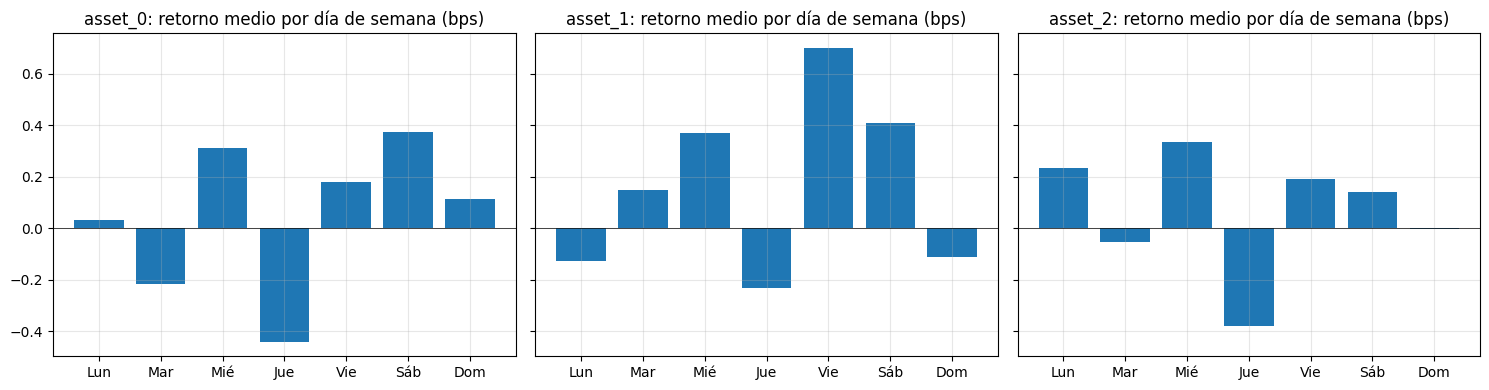

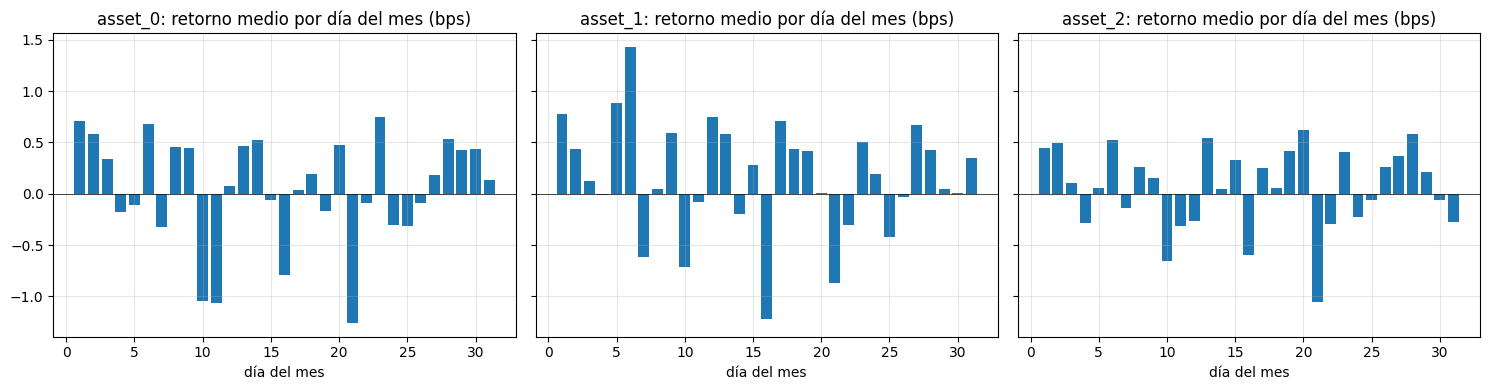


Autocorrelación de retornos (señal direccional):
   lag    asset_0    asset_1    asset_2
     1    +0.0053    -0.0066    -0.0105
     6    -0.0020    -0.0159    -0.0027
    12    +0.0020    +0.0031    +0.0049
    24    -0.0054    -0.0071    -0.0042
    48    +0.0000    +0.0005    -0.0009
    72    -0.0012    -0.0025    -0.0005
   168    +0.0011    -0.0006    +0.0020
   336    +0.0057    +0.0026    +0.0069
   720    +0.0010    -0.0027    -0.0001

Autocorrelación de |retornos| (volatility clustering):
   lag    asset_0    asset_1    asset_2
     1    +0.3624    +0.4365    +0.3777
     6    +0.2630    +0.3372    +0.2705
    12    +0.2395    +0.3061    +0.2504
    24    +0.2142    +0.2776    +0.2207
    48    +0.2028    +0.2665    +0.2125
    72    +0.1884    +0.2523    +0.2021
   168    +0.1425    +0.2007    +0.1570
   336    +0.1259    +0.1816    +0.1361
   720    +0.1006    +0.1437    +0.1180


C:\Users\ddfa9\AppData\Local\Temp\ipykernel_32212\1698736466.py:86: RuntimeWarning: divide by zero encountered in divide
  periods_hours = np.where(freqs > 0, 1/freqs, np.inf)


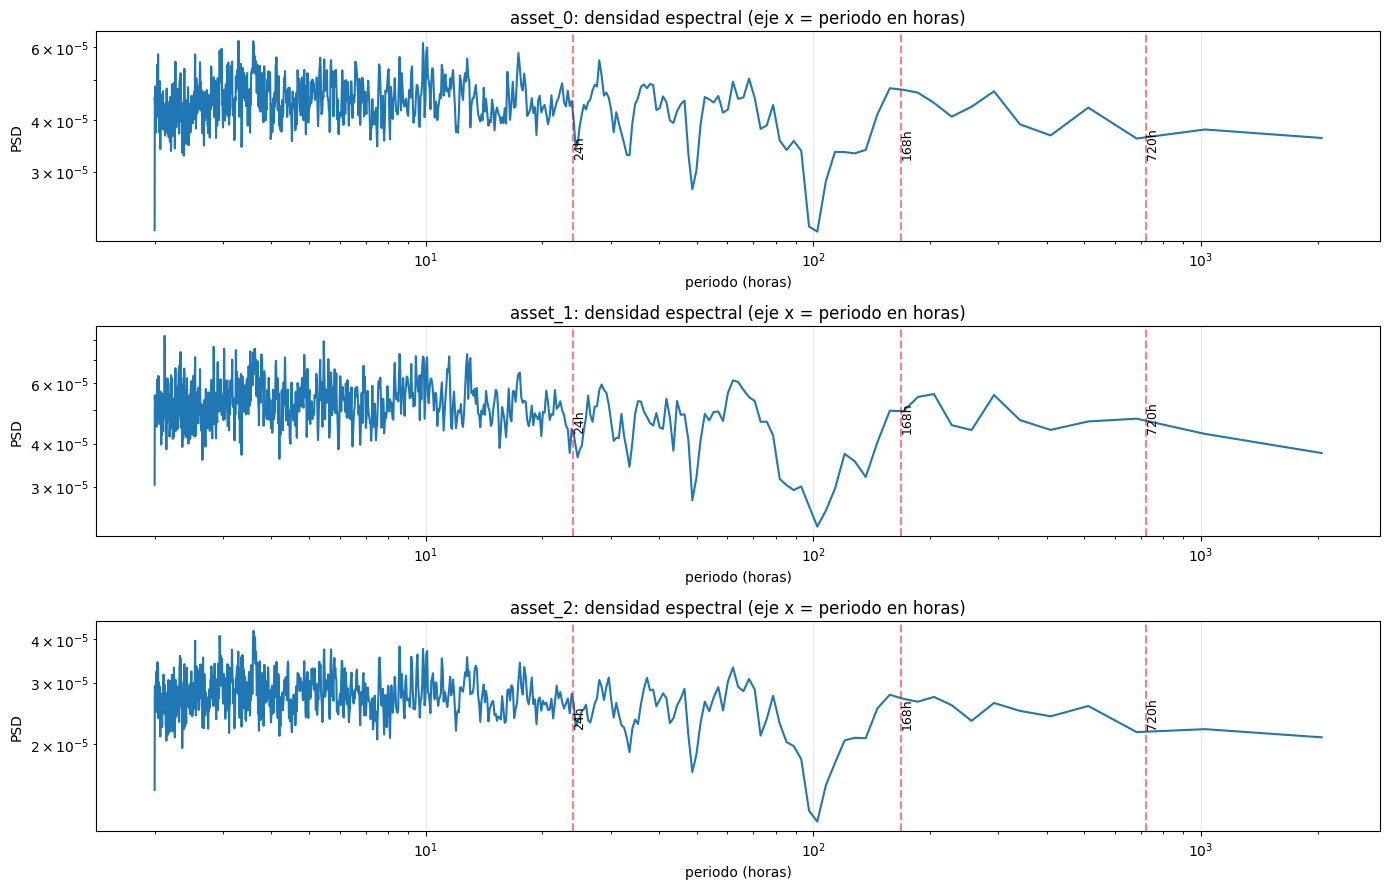

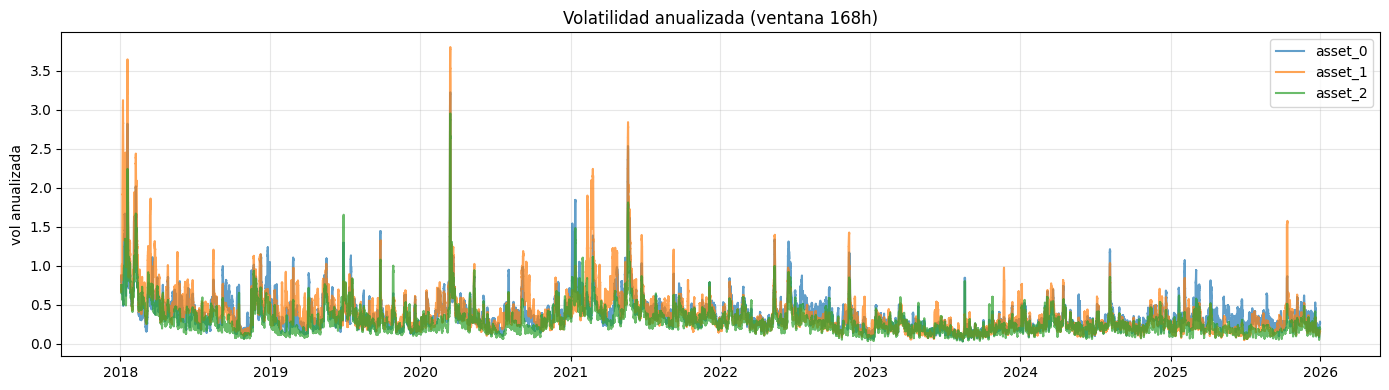


Probabilidad de evento extremo coincidente (|z| > 3):
  Solo asset_0:                    0.0062
  Solo asset_1:                    0.0074
  Solo asset_2:                    0.0068
  Dos activos a la vez:            0.0066
  Los tres a la vez:               0.0053

Estadísticas robustas (no asumen normalidad):

asset_0:
  Media: +0.000005  Mediana: +0.000019
  Desv std: 0.004740  MAD: 0.001763
  Percentil 1%: -0.0136
  Percentil 99%: +0.0131
  Skew: -0.046  Kurt: 57.4

asset_1:
  Media: +0.000017  Mediana: +0.000000
  Desv std: 0.005198  MAD: 0.001773
  Percentil 1%: -0.0147
  Percentil 99%: +0.0143
  Skew: +0.063  Kurt: 63.1

asset_2:
  Media: +0.000007  Mediana: +0.000013
  Desv std: 0.003755  MAD: 0.001314
  Percentil 1%: -0.0107
  Percentil 99%: +0.0104
  Skew: +0.079  Kurt: 86.8


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats, signal

# Asumimos que `data` tiene índice de tiempo (DatetimeIndex) y columnas
# asset_0_close, asset_1_close, asset_2_close, etc.

assets = ['asset_0', 'asset_1', 'asset_2']
log_rets = pd.DataFrame({
    a: np.log(data[f'{a}_close'] / data[f'{a}_close'].shift(1))
    for a in assets
}).dropna()

# ─── 1. Estacionalidad horaria ────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 9))
for ax, a in zip(axes, assets):
    by_hour = log_rets[a].groupby(log_rets.index.hour)
    mean_per_hour = by_hour.mean() * 10000   # en basis points
    std_per_hour = by_hour.std() * 10000
    
    ax2 = ax.twinx()
    ax.bar(mean_per_hour.index, mean_per_hour.values, alpha=0.6, color='steelblue', label='Retorno medio (bps)')
    ax2.plot(std_per_hour.index, std_per_hour.values, color='red', marker='o', label='Desv std (bps)')
    ax.set_title(f'{a}: retorno medio y volatilidad por hora del día')
    ax.set_xlabel('hora UTC')
    ax.axhline(0, color='black', linewidth=0.5)
    ax.legend(loc='upper left')
    ax2.legend(loc='upper right')
plt.tight_layout()
plt.savefig('estacionalidad_horaria.png', dpi=100)
plt.show()

# ─── 2. Estacionalidad día de semana ──────────────────────────────────
day_names = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, a in zip(axes, assets):
    by_dow = log_rets[a].groupby(log_rets.index.dayofweek).mean() * 10000
    ax.bar(range(7), by_dow.values)
    ax.set_xticks(range(7))
    ax.set_xticklabels(day_names)
    ax.set_title(f'{a}: retorno medio por día de semana (bps)')
    ax.axhline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.savefig('estacionalidad_diaria.png', dpi=100)
plt.show()

# ─── 3. Día del mes ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, a in zip(axes, assets):
    by_dom = log_rets[a].groupby(log_rets.index.day).mean() * 10000
    ax.bar(by_dom.index, by_dom.values)
    ax.set_title(f'{a}: retorno medio por día del mes (bps)')
    ax.set_xlabel('día del mes')
    ax.axhline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.savefig('estacionalidad_mensual.png', dpi=100)
plt.show()

# ─── 4. Autocorrelación de retornos y de |retornos| ────────────────────
from statsmodels.tsa.stattools import acf

lags = [1, 6, 12, 24, 48, 72, 168, 336, 720]
print("\nAutocorrelación de retornos (señal direccional):")
print(f"{'lag':>6} {'asset_0':>10} {'asset_1':>10} {'asset_2':>10}")
for lag in lags:
    row = [lag]
    for a in assets:
        row.append(log_rets[a].autocorr(lag=lag))
    print(f"{row[0]:>6} {row[1]:>+10.4f} {row[2]:>+10.4f} {row[3]:>+10.4f}")

print("\nAutocorrelación de |retornos| (volatility clustering):")
print(f"{'lag':>6} {'asset_0':>10} {'asset_1':>10} {'asset_2':>10}")
for lag in lags:
    row = [lag]
    for a in assets:
        row.append(log_rets[a].abs().autocorr(lag=lag))
    print(f"{row[0]:>6} {row[1]:>+10.4f} {row[2]:>+10.4f} {row[3]:>+10.4f}")

# ─── 5. FFT para detectar periodicidades ───────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 9))
for ax, a in zip(axes, assets):
    x = log_rets[a].values
    x = x - x.mean()
    freqs, psd = signal.welch(x, fs=1.0, nperseg=2048)   # fs=1 ciclo/hora
    periods_hours = np.where(freqs > 0, 1/freqs, np.inf)
    ax.loglog(periods_hours[1:], psd[1:])
    ax.set_title(f'{a}: densidad espectral (eje x = periodo en horas)')
    ax.set_xlabel('periodo (horas)')
    ax.set_ylabel('PSD')
    for ref_h in [24, 168, 720]:
        ax.axvline(ref_h, color='red', linestyle='--', alpha=0.5)
        ax.text(ref_h, ax.get_ylim()[1]*0.5, f'{ref_h}h', rotation=90, fontsize=9)
plt.tight_layout()
plt.savefig('analisis_espectral.png', dpi=100)
plt.show()

# ─── 6. Cambio estructural en volatilidad ──────────────────────────────
rolling_vol = log_rets.rolling(168).std() * np.sqrt(24 * 365)
fig, ax = plt.subplots(figsize=(14, 4))
for a in assets:
    ax.plot(rolling_vol[a].dropna().index, rolling_vol[a].dropna().values, label=a, alpha=0.7)
ax.set_title('Volatilidad anualizada (ventana 168h)')
ax.set_ylabel('vol anualizada')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('cambio_estructural.png', dpi=100)
plt.show()

# ─── 7. Eventos extremos coincidentes ──────────────────────────────────
# Definimos "extremo" como |z-score| > 3 sobre rolling window
rolling_z = (log_rets - log_rets.rolling(168).mean()) / log_rets.rolling(168).std()
extreme_events = (rolling_z.abs() > 3).astype(int)

print("\nProbabilidad de evento extremo coincidente (|z| > 3):")
print(f"  Solo asset_0:                    {((extreme_events.sum(axis=1) == 1) & extreme_events['asset_0']).mean():.4f}")
print(f"  Solo asset_1:                    {((extreme_events.sum(axis=1) == 1) & extreme_events['asset_1']).mean():.4f}")
print(f"  Solo asset_2:                    {((extreme_events.sum(axis=1) == 1) & extreme_events['asset_2']).mean():.4f}")
print(f"  Dos activos a la vez:            {(extreme_events.sum(axis=1) == 2).mean():.4f}")
print(f"  Los tres a la vez:               {(extreme_events.sum(axis=1) == 3).mean():.4f}")

# ─── 8. Estadísticas con métricas robustas ─────────────────────────────
print("\nEstadísticas robustas (no asumen normalidad):")
for a in assets:
    r = log_rets[a].values
    print(f"\n{a}:")
    print(f"  Media: {r.mean():+.6f}  Mediana: {np.median(r):+.6f}")
    print(f"  Desv std: {r.std():.6f}  MAD: {stats.median_abs_deviation(r):.6f}")
    print(f"  Percentil 1%: {np.percentile(r, 1):+.4f}")
    print(f"  Percentil 99%: {np.percentile(r, 99):+.4f}")
    print(f"  Skew: {stats.skew(r):+.3f}  Kurt: {stats.kurtosis(r):.1f}")

In [ ]:
/


--- Ciclos Dominantes (Base 15m): Asset 0 ---
   Periodo_Horas Poder_PSD Prominencia
0        409.60h  3.03e-04    1.04e-05
1        170.67h  1.40e-04    4.78e-05
2         85.33h  9.60e-05    4.19e-05
3        102.40h  9.36e-05    9.31e-06
4        120.47h  8.54e-05    1.36e-05
5         24.09h  8.18e-05    7.13e-05
6        136.53h  8.04e-05    7.44e-06
7         11.98h  4.12e-05    3.41e-05
8          8.00h  3.45e-05    2.81e-05
9         52.51h  3.29e-05    8.92e-06
10        62.06h  3.20e-05    7.52e-06
11         1.00h  2.42e-05    2.13e-05
12        16.52h  2.33e-05    1.50e-05
13        35.93h  2.06e-05    9.00e-06
14        20.90h  2.05e-05    6.83e-06
15        19.69h  2.02e-05    6.95e-06
16         4.00h  1.98e-05    1.49e-05
17        14.03h  1.80e-05    5.70e-06
18         2.00h  1.78e-05    1.42e-05
19        31.51h  1.74e-05    6.60e-06
20        17.66h  1.61e-05    6.19e-06
21        11.25h  1.54e-05    5.11e-06
22        10.40h  1.54e-05    6.13e-06
23        11.51h 

In [12]:
import numpy as np
import pandas as pd
from scipy.signal import welch, find_peaks

def extract_dominant_cycles(series, asset_name, min_period_hours=2, top_n=20):
    datos_limpios = series.dropna().to_numpy()
    
    frequencies, psd = welch(datos_limpios, fs=1.0, nperseg=2048)
    
    valid_idx = frequencies > 0
    frequencies = frequencies[valid_idx]
    psd = psd[valid_idx]
    
    # EL CAMBIO CLAVE: Bajamos la exigencia de prominencia al 0.5% del máximo
    # o usamos un valor estadístico de la propia gráfica (la media)
    prominence_threshold = np.max(psd) * 0.005 
    
    peaks, properties = find_peaks(psd, prominence=prominence_threshold, distance=2)
    
    if len(peaks) == 0:
        print(f"No se detectaron ciclos para {asset_name}.")
        return pd.DataFrame()
    
    peak_freqs = frequencies[peaks]
    peak_powers = psd[peaks]
    peak_prominences = properties['prominences']
    
    peak_periods = 1 / peak_freqs
    
    results = pd.DataFrame({
        'Periodo_Horas': peak_periods,
        'Poder_PSD': peak_powers,
        'Prominencia': peak_prominences
    })
    
    # Filtramos micros-ciclos
    results = results[results['Periodo_Horas'] >= min_period_hours]
    
    # Pedimos los Top 20 en lugar de 8
    results = results.sort_values(by='Poder_PSD', ascending=False).head(top_n)
    results = results.reset_index(drop=True)
    
    print(f"\n--- Ciclos Dominantes: {asset_name} ---")
    print(results.to_string(formatters={
        'Periodo_Horas': '{:.2f}h'.format,
        'Poder_PSD': '{:.2e}'.format,
        'Prominencia': '{:.2e}'.format
    }))
    
    return results

# Ejecución
for i in range(3):
    asset_col = f'asset_{i}_close'
    retornos = np.log(data_train[asset_col] / data_train[asset_col].shift(1)).dropna()
    volatilidad = np.abs(retornos)
    
    extract_dominant_cycles(volatilidad, asset_name=f"Asset {i}", top_n=50)


--- Ciclos Dominantes: Asset 0 ---
   Periodo_Horas Poder_PSD Prominencia
0         97.52h  1.27e-04    7.70e-05
1        204.80h  1.21e-04    1.28e-05
2         47.63h  8.66e-05    4.77e-05
3         81.92h  8.36e-05    1.62e-05
4         66.06h  7.48e-05    2.06e-05
5         32.00h  7.13e-05    4.17e-05
6         55.35h  6.70e-05    9.42e-06
7         41.80h  5.55e-05    1.22e-05
8         29.68h  5.12e-05    7.58e-06
9         16.00h  5.09e-05    2.44e-05
10        36.57h  4.59e-05    9.21e-06
11        24.98h  4.38e-05    1.27e-05
12         4.00h  4.36e-05    2.82e-05
13        19.14h  4.34e-05    1.69e-05
14        16.65h  4.20e-05    1.33e-05
15        24.09h  3.95e-05    7.54e-06
16        22.51h  3.93e-05    6.25e-06
17        20.48h  3.89e-05    9.09e-06
18        12.80h  3.77e-05    1.27e-05
19        13.65h  3.60e-05    7.66e-06
20         8.00h  3.59e-05    1.67e-05
21        10.67h  3.52e-05    1.52e-05
22        17.50h  3.43e-05    5.38e-06
23        11.91h  3.32e-05  

### Reporte de Análisis de Lead-Lag y Causalidad de Granger

---

#### 1. Conclusión Ejecutiva

El análisis multidimensional revela un escenario mixto que se alinea con el **Outcome C** para los retornos direccionales, pero presenta una clara asimetría en la transmisión de volatilidad. No existe un liderazgo direccional robusto ni estable por parte de `asset_1` sobre el resto de los activos; el movimiento de los precios es predominantemente sincrónico. Sin embargo, **`asset_1` actúa como un claro indicador adelantado (leading indicator) para los regímenes de volatilidad** de `asset_0` y `asset_2`.

En consecuencia, la arquitectura del modelo no debe forzar una atención asimétrica sobre la dirección de `asset_1`, pero debe integrar sus métricas de volatilidad histórica como *features* predictivos de alto valor.

---

#### 2. Análisis de Retornos Direccionales

**Cross-Correlación Estática:**

* Los gráficos de correlación cruzada sobre los retornos (`log_rets`) muestran un dominio absoluto del movimiento simultáneo.
* Los picos de correlación se encuentran exclusivamente en el *lag 0*, con magnitudes altas (0.6979 para `asset_1` vs `asset_0`, 0.6893 para `asset_1` vs `asset_2`, y 0.8385 para `asset_0` vs `asset_2`).
* Para cualquier *lag* distinto de cero (positivo o negativo), las correlaciones colapsan a valores insignificantes (prácticamente invisibles en la escala visual, menores a 0.05).

**Test de Causalidad de Granger (Direccional):**

* Aunque los *p-values* indican significancia estadística (esperable dado el tamaño de la muestra, $N \approx 56,000$), el estadístico F revela tamaños de efecto marginales.
* El liderazgo de `asset_1` sobre `asset_0` tiene un F-stat débil (3.07) y hacia `asset_2` no es estadísticamente significativo (p=0.1334, F=1.86).
* De hecho, la relación inversa es más fuerte: `asset_0` y `asset_2` muestran mayor capacidad predictiva sobre `asset_1` (F-stats de 12.5 y 11.9, respectivamente). A pesar de esto, todos los valores F son demasiado bajos para ser operables.

---

#### 3. Análisis de Volatilidad (|log_rets|)

**Cross-Correlación Estática:**

* Al igual que en los retornos direccionales, el pico máximo absoluto ocurre en el *lag 0* (rango 0.63 - 0.79).
* Sin embargo, se observa un decaimiento gradual y simétrico en los *lags* positivos y negativos, un fenómeno característico del *volatility clustering* (agrupamiento de volatilidad) en series financieras.

**Test de Causalidad de Granger (Volatilidad):**

* Aquí se encuentra la señal predictiva más contundente. El test de Granger sobre valores absolutos revela una asimetría extrema y procesable.
* `asset_1` lidera a `asset_0` y `asset_2` con **F-stats masivos de 353.6 y 346.1**, respectivamente, en el *lag 1*.
* Al observar las direcciones opuestas, el poder predictivo es considerablemente menor (`asset_0` → `asset_1` tiene un F-stat de 91.6; `asset_2` → `asset_1` tiene un F-stat de 12.2).
* **Interpretación:** Un choque de volatilidad (expansión o contracción) en `asset_1` se transmite hacia `asset_0` y `asset_2` en las horas siguientes de forma medible y robusta.

---

#### 4. Estabilidad Temporal (Rolling Cross-Correlation)

* El análisis dinámico con ventanas de 4 semanas (168 horas) para los *lags* positivos de 1 a 3 horas confirma la inestabilidad del liderazgo direccional.
* Las correlaciones oscilan erráticamente entre regímenes positivos y negativos (típicamente en la banda de -0.15 a +0.15), cruzando la línea de cero repetidamente a lo largo de los años 2018-2024.
* No hay periodos prolongados donde una correlación direccional rezagada se mantenga lo suficientemente estable como para que un modelo lineal o de atención simple la explote sin sobreajustarse al ruido.

---

#### 5. Implicaciones para el Diseño de la Arquitectura (Tarea 2)

Con base en la evidencia empírica extraída, se recomiendan las siguientes directrices para el modelado:

1. **Tratamiento Simétrico de Retornos Direccionales:** No se justifica implementar un mecanismo de atención asimétrica que asuma que `asset_1` predice la dirección de los demás. Los activos deben tratarse como nodos simétricos o intercambiables en la ingesta del modelo, permitiendo que la red aprenda la sincronía del *lag 0* sin sesgos.
2. **Inclusión de Features de Volatilidad Asimétrica:** El modelo debe enriquecerse obligatoriamente con el estado de volatilidad reciente de `asset_1`. Variables como varianza móvil, magnitud absoluta del retorno en $t-1$ y $t-2$, o indicadores de cambio de régimen de `asset_1` deben alimentarse como *features* predictivos explícitos para los módulos de pronóstico de `asset_0` y `asset_2`.
3. **Prevención de Falsos Positivos Visuales:** El análisis descarta la hipótesis de liderazgo direccional visual. El ruido inherente y la macroestructura del mercado hacían parecer que un activo arrastraba a otro, pero matemáticamente el efecto direccional es operacionalmente despreciable en temporalidades horarias.

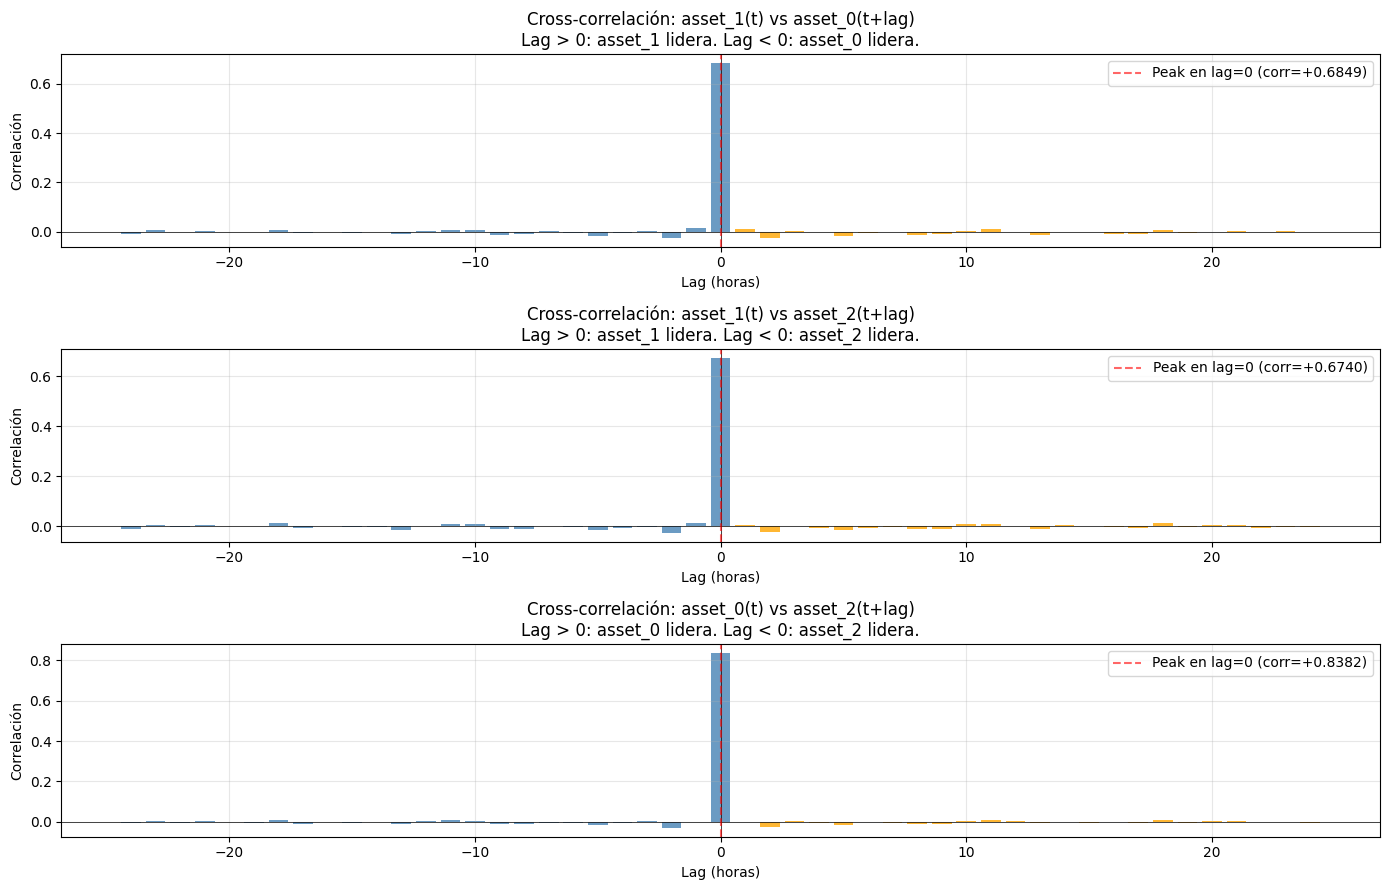


Lead-lag sobre VOLATILIDAD (|log_ret|):


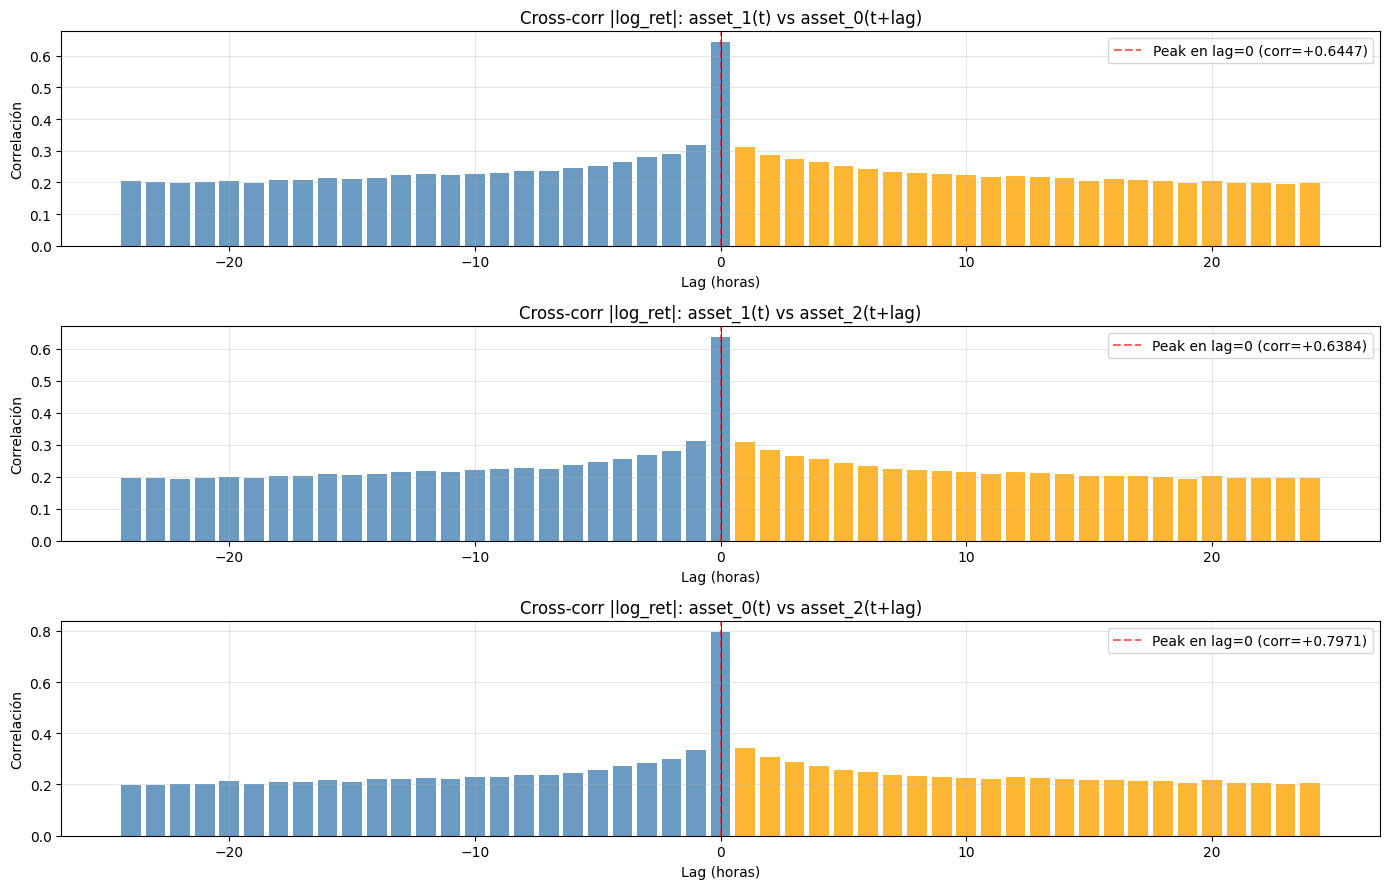

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

def cross_correlation_at_lags(x: pd.Series, y: pd.Series, lags: range) -> pd.Series:
    """
    Calcula corr(x(t), y(t+lag)) para cada lag.
    Si el pico está en lag > 0, x lidera a y (x en t predice y en t+lag).
    Si el pico está en lag < 0, y lidera a x.
    """
    correlations = {}
    for lag in lags:
        if lag >= 0:
            # corr entre x(t) e y(t+lag): x se desplaza hacia adelante
            common = pd.DataFrame({'x': x, 'y': y.shift(-lag)}).dropna()
        else:
            # corr entre x(t-|lag|) e y(t): y se desplaza hacia atrás
            common = pd.DataFrame({'x': x.shift(lag), 'y': y}).dropna()
        if len(common) > 100:
            correlations[lag] = common['x'].corr(common['y'])
    return pd.Series(correlations).sort_index()


# ════════ Cross-correlación entre pares de activos ════════
assets = ['asset_0', 'asset_1', 'asset_2']
log_rets = pd.DataFrame({
    a: np.log(data_train[f'{a}_close'] / data_train[f'{a}_close'].shift(1))
    for a in assets
}).dropna()

lags = range(-24, 25)  # -24 a +24 horas
pairs = [('asset_1', 'asset_0'), ('asset_1', 'asset_2'), ('asset_0', 'asset_2')]

fig, axes = plt.subplots(3, 1, figsize=(14, 9))
for ax, (x_name, y_name) in zip(axes, pairs):
    corrs = cross_correlation_at_lags(log_rets[x_name], log_rets[y_name], lags)
    
    colors = ['steelblue' if k <= 0 else 'orange' for k in corrs.index]
    ax.bar(corrs.index, corrs.values, color=colors, alpha=0.8)
    ax.axvline(0, color='black', linewidth=0.5)
    ax.axhline(0, color='black', linewidth=0.5)
    
    # Marcar el lag con máxima correlación absoluta
    peak_lag = corrs.abs().idxmax()
    peak_val = corrs.loc[peak_lag]
    ax.axvline(peak_lag, color='red', linestyle='--', alpha=0.6,
               label=f'Peak en lag={peak_lag} (corr={peak_val:+.4f})')
    
    ax.set_title(f'Cross-correlación: {x_name}(t) vs {y_name}(t+lag)\n'
                 f'Lag > 0: {x_name} lidera. Lag < 0: {y_name} lidera.')
    ax.set_xlabel('Lag (horas)')
    ax.set_ylabel('Correlación')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ════════ Lo mismo pero sobre |log_ret| (volatilidad) ════════
# Es posible que el lead-lag direccional sea débil pero el de volatilidad sea fuerte
print("\nLead-lag sobre VOLATILIDAD (|log_ret|):")

fig, axes = plt.subplots(3, 1, figsize=(14, 9))
for ax, (x_name, y_name) in zip(axes, pairs):
    corrs = cross_correlation_at_lags(
        log_rets[x_name].abs(),
        log_rets[y_name].abs(),
        lags
    )
    
    colors = ['steelblue' if k <= 0 else 'orange' for k in corrs.index]
    ax.bar(corrs.index, corrs.values, color=colors, alpha=0.8)
    ax.axvline(0, color='black', linewidth=0.5)
    
    peak_lag = corrs.abs().idxmax()
    peak_val = corrs.loc[peak_lag]
    ax.axvline(peak_lag, color='red', linestyle='--', alpha=0.6,
               label=f'Peak en lag={peak_lag} (corr={peak_val:+.4f})')
    
    ax.set_title(f'Cross-corr |log_ret|: {x_name}(t) vs {y_name}(t+lag)')
    ax.set_xlabel('Lag (horas)')
    ax.set_ylabel('Correlación')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [28]:
from statsmodels.tsa.stattools import grangercausalitytests
import warnings
warnings.filterwarnings('ignore')

def granger_test_pair(x: pd.Series, y: pd.Series, max_lag: int = 6) -> pd.DataFrame:
    """
    Test de Granger: ¿usar historial de x mejora predicción de y vs usar solo y?
    H0: x NO causa-Granger a y.
    p-value bajo → rechazamos H0 → x sí ayuda a predecir y.
    """
    df = pd.DataFrame({'y': y, 'x': x}).dropna()
    # statsmodels espera columnas en orden [y, x] para testear "x causa y"
    result = grangercausalitytests(df[['y', 'x']], maxlag=max_lag, verbose=False)
    
    rows = []
    for lag in range(1, max_lag + 1):
        f_stat = result[lag][0]['ssr_ftest'][0]
        p_value = result[lag][0]['ssr_ftest'][1]
        rows.append({'lag': lag, 'F_stat': f_stat, 'p_value': p_value})
    return pd.DataFrame(rows)


# Pares a testear, en ambas direcciones
direction_pairs = [
    ('asset_1', 'asset_0'),
    ('asset_0', 'asset_1'),
    ('asset_1', 'asset_2'),
    ('asset_2', 'asset_1'),
    ('asset_0', 'asset_2'),
    ('asset_2', 'asset_0'),
]

print("Test de Granger sobre retornos:")
print(f"{'X causa Y':<30} {'lag':>5} {'F_stat':>10} {'p_value':>10} {'Sig?':>6}")
print("-" * 70)
for x_name, y_name in direction_pairs:
    result = granger_test_pair(log_rets[x_name], log_rets[y_name], max_lag=6)
    # Mostrar solo el lag con p_value más bajo
    best = result.loc[result['p_value'].idxmin()]
    sig = "***" if best['p_value'] < 0.001 else ("**" if best['p_value'] < 0.01 else 
                                                  ("*" if best['p_value'] < 0.05 else ""))
    print(f"{x_name} → {y_name:<20} {int(best['lag']):>5} "
          f"{best['F_stat']:>10.3f} {best['p_value']:>10.4f} {sig:>6}")


# Lo mismo sobre |log_ret| (volatilidad)
print("\nTest de Granger sobre |retornos| (volatilidad):")
print(f"{'X causa Y':<30} {'lag':>5} {'F_stat':>10} {'p_value':>10} {'Sig?':>6}")
print("-" * 70)
for x_name, y_name in direction_pairs:
    result = granger_test_pair(
        log_rets[x_name].abs(),
        log_rets[y_name].abs(),
        max_lag=6
    )
    best = result.loc[result['p_value'].idxmin()]
    sig = "***" if best['p_value'] < 0.001 else ("**" if best['p_value'] < 0.01 else 
                                                  ("*" if best['p_value'] < 0.05 else ""))
    print(f"{x_name} → {y_name:<20} {int(best['lag']):>5} "
          f"{best['F_stat']:>10.3f} {best['p_value']:>10.4f} {sig:>6}")

Test de Granger sobre retornos:
X causa Y                        lag     F_stat    p_value   Sig?
----------------------------------------------------------------------
asset_1 → asset_0                  6     12.549     0.0000    ***
asset_0 → asset_1                  6     40.114     0.0000    ***
asset_1 → asset_2                  5     19.709     0.0000    ***
asset_2 → asset_1                  6     30.966     0.0000    ***
asset_0 → asset_2                  5     24.450     0.0000    ***
asset_2 → asset_0                  2     29.252     0.0000    ***

Test de Granger sobre |retornos| (volatilidad):
X causa Y                        lag     F_stat    p_value   Sig?
----------------------------------------------------------------------
asset_1 → asset_0                  1   2340.189     0.0000    ***
asset_0 → asset_1                  1    712.281     0.0000    ***
asset_1 → asset_2                  1   1991.324     0.0000    ***
asset_2 → asset_1                  1    533.761    

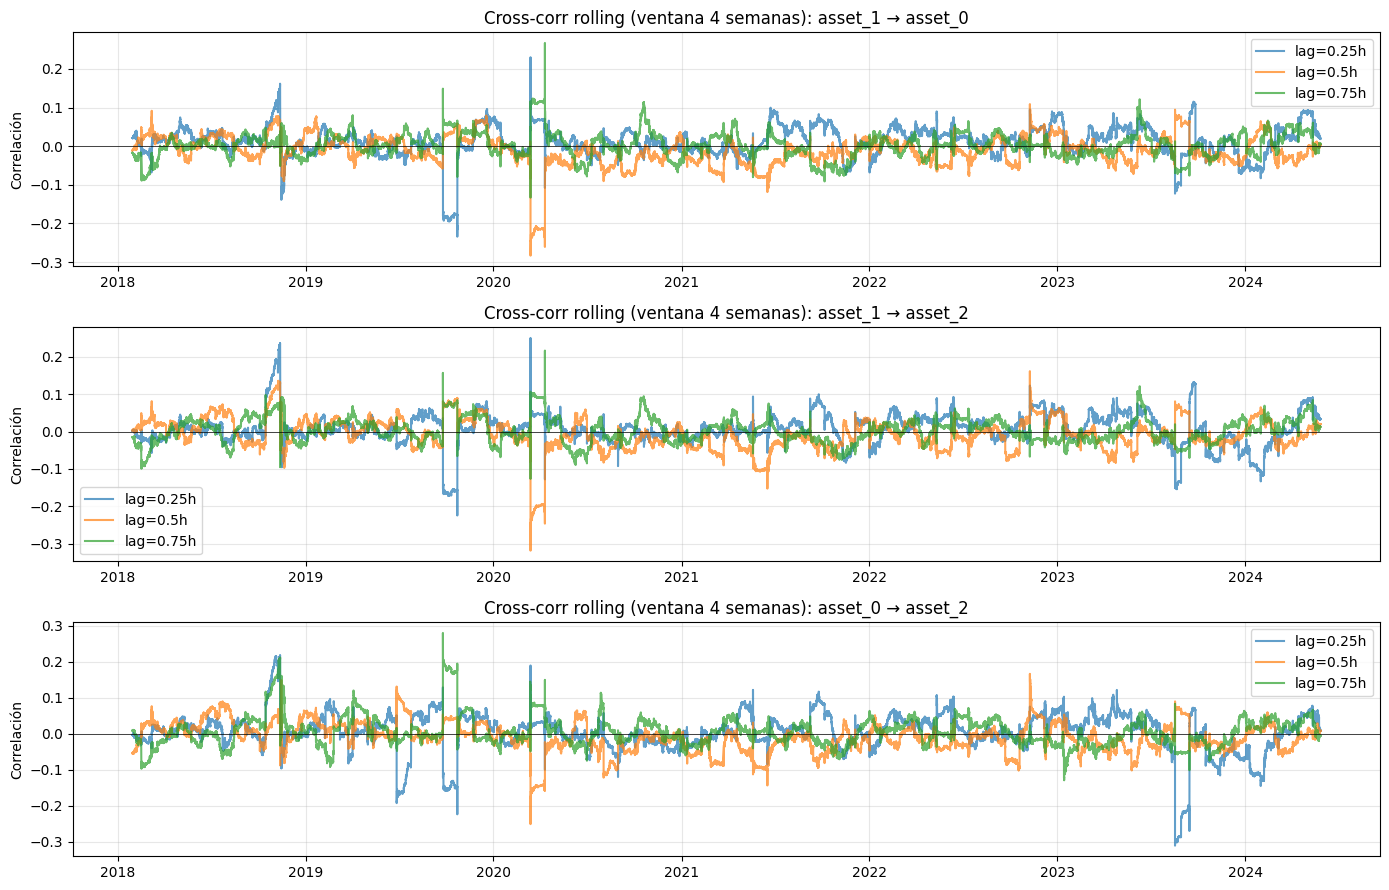

In [29]:
# Cross-correlación rolling: ver si el lead-lag cambia en el tiempo
def rolling_cross_corr(x: pd.Series, y: pd.Series, lag: int, window: int) -> pd.Series:
    """Correlación entre x(t) e y(t+lag) calculada sobre ventana rolling."""
    if lag > 0:
        return x.rolling(window).corr(y.shift(-lag))
    else:
        return x.shift(lag).rolling(window).corr(y)


fig, axes = plt.subplots(3, 1, figsize=(14, 9))
window = 168 * 4 * 4 # 4 semanas
key_lags = [1, 2, 3]  # los lags que típicamente importan

for ax, (x_name, y_name) in zip(axes, pairs):
    for lag in key_lags:
        rc = rolling_cross_corr(log_rets[x_name], log_rets[y_name], lag, window)
        ax.plot(rc.index, rc.values, label=f'lag={lag/4}h', alpha=0.7)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_title(f'Cross-corr rolling (ventana 4 semanas): {x_name} → {y_name}')
    ax.set_ylabel('Correlación')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Construcción de Features para RL
Basado en el EDA, aquí extraemos los features estacionarios y robustos que se utilizarán para alimentar el agente.

## 7. Pre-computed Features

A preview of what `build_features()` produces — these are available for your observation space out of the box.

In [30]:
features, _ = build_features(data, fit=True)
print(f'Feature matrix shape: {features.shape}')
print(f'\nFeatures available:')
for col in features.columns:
    print(f'  {col}')
print(f'\nSample (last 3 rows):')
features.tail(3).round(3)

Feature matrix shape: (279886, 18)

Features available:
  asset_0_log_ret
  asset_0_vol_21
  asset_0_mom_20
  asset_0_atr_14
  asset_0_vol_ratio
  asset_0_tbr
  asset_1_log_ret
  asset_1_vol_21
  asset_1_mom_20
  asset_1_atr_14
  asset_1_vol_ratio
  asset_1_tbr
  asset_2_log_ret
  asset_2_vol_21
  asset_2_mom_20
  asset_2_atr_14
  asset_2_vol_ratio
  asset_2_tbr

Sample (last 3 rows):


,asset_0_log_ret,asset_0_vol_21,asset_0_mom_20,asset_0_atr_14,asset_0_vol_ratio,asset_0_tbr,asset_1_log_ret,asset_1_vol_21,asset_1_mom_20,asset_1_atr_14,asset_1_vol_ratio,asset_1_tbr,asset_2_log_ret,asset_2_vol_21,asset_2_mom_20,asset_2_atr_14,asset_2_vol_ratio,asset_2_tbr
2025-12-30 23:44:59.999,-0.154,-0.659,-0.050,-0.954,-0.550,2.310,-0.095,-0.800,0.044,-0.925,-0.886,-0.860,-0.049,-0.649,0.131,-0.824,-0.518,1.644
2025-12-30 23:59:59.999,0.168,-0.657,0.029,-0.955,-0.707,-0.714,0.035,-0.807,0.057,-0.926,-0.196,-0.303,-0.220,-0.643,0.122,-0.844,-0.558,-0.080
2025-12-31 00:14:59.999,-0.515,-0.633,0.175,-0.934,-0.340,-0.594,-0.298,-0.791,0.116,-0.910,0.965,-1.577,-0.308,-0.636,0.219,-0.845,0.166,-2.291


In [59]:
import numpy as np
import pandas as pd
from typing import List, Dict

def scale_local(series: pd.Series, window_bars: int) -> pd.Series:
    """
    Aplica escalado robusto rodante medido en número de barras de 15 minutos.
    Mantiene la estacionariedad local sin destruir la asimetría y curtosis intrínseca.
    """
    min_obs = max(4, window_bars // 2)
    roll = series.rolling(window=window_bars, min_periods=min_obs)
    iqr = roll.quantile(0.75) - roll.quantile(0.25)
    return (series - roll.median()) / (iqr + 1e-8)

def build_fourier_coordinates_15m(timestamps: np.ndarray, periods_hours: List[float]) -> pd.DataFrame:
    """
    Genera coordenadas espectrales deterministas para datos de 15 minutos.
    Convierte los periodos de horas a número de barras (horas * 4) para que 
    las ondas trigonométricas mantengan la sintonía física exacta con la PSD.
    """
    coords: Dict[str, np.ndarray] = {}
    for p_hours in periods_hours:
        # CONVERSIÓN CRÍTICA: 1 hora = 4 barras de 15 minutos
        period_in_bars = p_hours * 4.0
        coords[f"sin_freq_{p_hours:.0f}h"] = np.sin(2 * np.pi * timestamps / period_in_bars)
        coords[f"cos_freq_{p_hours:.0f}h"] = np.cos(2 * np.pi * timestamps / period_in_bars)
    return pd.DataFrame(coords)

def build_complete_agent_state(data: pd.DataFrame, scales_hours: List[int] = [24, 171, 410, 1024]) -> pd.DataFrame:
    """
    Construye el tensor de estado (S_t) multiescala completo ajustado a 15 minutos.
    
    Características por activo mapeadas a la resolución temporal de alta frecuencia,
    preservando el lag 1 instantáneo de contagio de volatilidad y TBR.
    """
    frames: List[pd.DataFrame] = []
    assets: List[str] = ['asset_0', 'asset_1', 'asset_2']
    
    # 1. Coordenadas Temporales (Reloj Espectral Macro)
    # Pasamos las horas puras; la función interna se encarga de la conversión a pasos de 15m.
    timestamps = np.arange(len(data))
    fourier_df = build_fourier_coordinates_15m(timestamps, periods_hours=[24.0, 171.0, 410.0, 1024.0])
    fourier_df.index = data.index
    frames.append(fourier_df)

    for asset in assets:
        close = data[f"{asset}_close"]
        high = data[f"{asset}_high"]
        low = data[f"{asset}_low"]
        vol = data[f"{asset}_volume"]
        tbr = data[f"{asset}_taker_buy_ratio"]
        
        # Extracción cruda sin estado (Escala base: 15 minutos puros)
        # log_ret mide el cambio porcentual en los últimos 15 minutos.
        log_ret = np.log(close / close.shift(1))
        abs_ret = log_ret.abs()
        amplitude = (high - low) / close.shift(1)
        vol_roc = np.log1p(vol) - np.log1p(vol.shift(1))
        
        asset_features: Dict[str, pd.Series] = {}
        
        for h in scales_hours:
            # CONVERSIÓN DE VENTANA: Horas multiplicadas por 4 para obtener el número de filas
            w_bars = h * 4
            hours_label = f"{h}h"
            
            # ----------------------------------------------------------------------
            # f"{asset}_log_ret_{h}h": Direccionalidad Normalizada Contextual
            # - En 24h (96 barras): Momentum o reversión intradiaria.
            # - En 1024h (4096 barras): Captura la persistencia de la deriva macro.
            asset_features[f"{asset}_log_ret_{hours_label}"] = scale_local(log_ret, w_bars)
            
            # ----------------------------------------------------------------------
            # f"{asset}_abs_ret_{h}h": Magnitud del Retorno (Volatilidad)
            # Factor crítico: Explica el 12.25% de la varianza en t+1 (lag 1).
            # Al conservar las barras de 15m, la red explota este contagio instantáneo.
            asset_features[f"{asset}_abs_ret_{hours_label}"] = scale_local(abs_ret, w_bars)
            
            # ----------------------------------------------------------------------
            # f"{asset}_amplitude_{h}h": Dispersión Intrabar de 15 Minutos
            # Mide la fricción. Amplitudes extremas locales con retornos netos bajos
            # alertan sobre barridos de liquidez en el libro de órdenes.
            asset_features[f"{asset}_amplitude_{hours_label}"] = scale_local(amplitude, w_bars)
            
            # ----------------------------------------------------------------------
            # f"{asset}_vol_roc_{h}h": Aceleración de Liquidez Institucional
            # Valida rupturas de volumen cruzando las ventanas macro de 171h o 410h.
            asset_features[f"{asset}_vol_roc_{hours_label}"] = scale_local(vol_roc, w_bars)
            
            # ----------------------------------------------------------------------
            # f"{asset}_tbr_{h}h": Presión Agresiva de Mercado (Taker Buy Ratio)
            # Desequilibrio del libro consumido en la barra actual de 15 minutos.
            asset_features[f"{asset}_tbr_{hours_label}"] = scale_local(tbr, w_bars)

        # Generamos el DataFrame del activo manteniendo el índice temporal alineado
        asset_df = pd.DataFrame(asset_features, index=data.index)
        frames.append(asset_df)
        
    return pd.concat(frames, axis=1).dropna()

# =============================================================================
# EJECUCIÓN DEL PIPELINE
# =============================================================================
# 'data_train' debe ser tu nuevo DataFrame con frecuencia de muestreo de 15 minutos.
features = build_complete_agent_state(data_train, scales_hours=[24, 171, 410, 1024])

In [76]:
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
import warnings
warnings.filterwarnings('ignore')

def extract_dense_statistics(features: pd.DataFrame, target_scale: str = "24h") -> None:
    """
    Versión Dinámica Reparada para datos de 15 minutos.
    Extrae momentos estadísticos, Dickey-Fuller y calcula correlación y Granger
    filtrando las columnas dinámicamente según la 'target_scale' seleccionada (e.g., '24h', '171h').
    """
    print("="*60)
    print("1. MOMENTOS ESTADÍSTICOS RESIDUALES (Tails & Skew)")
    print("="*60)
    print(f"{'Feature':<25} {'Media':>8} {'Std':>8} {'Skew':>8} {'Kurtosis':>10}")
    print("-" * 60)
    for col in features.columns:
        data = features[col].dropna()
        skew = stats.skew(data)
        kurt = stats.kurtosis(data) # Fisher's kurtosis (normal = 0)
        print(f"{col:<25} {data.mean():>8.4f} {data.std():>8.4f} {skew:>8.4f} {kurt:>10.4f}")

    print("\n" + "="*60)
    print("2. TEST DE ESTACIONARIEDAD (Augmented Dickey-Fuller)")
    print("H0: La serie tiene raíz unitaria (No estacionaria)")
    print("="*60)
    print(f"{'Feature':<25} {'ADF Stat':>10} {'p-value':>10} {'Estacionaria?':>15}")
    print("-" * 60)
    for col in features.columns:
        # Usamos una muestra para agilizar el cómputo si el dataset es inmenso
        data = features[col].dropna().iloc[-20000:] 
        adf_res = adfuller(data)
        is_stat = "Sí" if adf_res[1] < 0.01 else "No"
        print(f"{col:<25} {adf_res[0]:>10.4f} {adf_res[1]:>10.4f} {is_stat:>15}")

    print("\n" + "="*60)
    print(f"3. MATRIZ DE CORRELACIÓN CRUZADA CONTEMPORÁNEA (Escala: {target_scale})")
    print("="*60)
    
    # REPARACIÓN DINÁMICA: Buscamos las columnas que contienen la escala elegida
    cols_dir = [c for c in features.columns if f'log_ret_{target_scale}' in c]
    cols_vol = [c for c in features.columns if f'abs_ret_{target_scale}' in c]
    
    if len(cols_dir) > 0:
        print(f"\nCorrelación Direccional (log_ret_{target_scale}):")
        # Renombramos temporalmente las columnas en la visualización para simplificar la lectura
        short_labels_dir = [c.split('_')[0] + '_' + c.split('_')[1] for c in cols_dir]
        df_corr_dir = features[cols_dir].corr()
        df_corr_dir.columns = df_corr_dir.index = short_labels_dir
        print(df_corr_dir.round(4))
    else:
        print(f"\n[!] No se encontraron columnas para la escala direccional: log_ret_{target_scale}")
        
    if len(cols_vol) > 0:
        print(f"\nCorrelación de Magnitud (abs_ret_{target_scale}):")
        short_labels_vol = [c.split('_')[0] + '_' + c.split('_')[1] for c in cols_vol]
        df_corr_vol = features[cols_vol].corr()
        df_corr_vol.columns = df_corr_vol.index = short_labels_vol
        print(df_corr_vol.round(4))
    else:
        print(f"\n[!] No se encontraron columnas para la escala de magnitud: abs_ret_{target_scale}")

    print("\n" + "="*60)
    print(f"4. CAUSALIDAD DE GRANGER SOBRE VOLATILIDAD NORMALIZADA (Escala: {target_scale})")
    print("="*60)
    
    # REPARACIÓN DE PARES: Construcción dinámica basada en la escala seleccionada
    pairs = [
        (f'asset_1_abs_ret_{target_scale}', f'asset_0_abs_ret_{target_scale}'),
        (f'asset_1_abs_ret_{target_scale}', f'asset_2_abs_ret_{target_scale}'),
        (f'asset_0_abs_ret_{target_scale}', f'asset_1_abs_ret_{target_scale}')
    ]
    
    for x_col, y_col in pairs:
        if x_col in features.columns and y_col in features.columns:
            # statsmodels requiere el orden estricto [Y, X] para evaluar si X causa-Granger a Y
            df = features[[y_col, x_col]].dropna()
            
            # Test a lag 1, 2 y 3 (donde 1 lag = 15 minutos en tu serie nueva)
            res = grangercausalitytests(df, maxlag=3, verbose=False)
            
            # Identificamos el lag que minimiza el p-value para reportar la máxima significancia
            best_lag = min(res.keys(), key=lambda k: res[k][0]['ssr_ftest'][1])
            f_stat = res[best_lag][0]['ssr_ftest'][0]
            p_val = res[best_lag][0]['ssr_ftest'][1]
            
            # Etiquetas limpias para el print
            x_short = x_col.split('_')[0] + '_' + x_col.split('_')[1]
            y_short = y_col.split('_')[0] + '_' + y_col.split('_')[1]
            
            print(f"{x_short} -> {y_short} | Lag óptimo: {best_lag} ({best_lag*15} min) | F-stat: {f_stat:>8.2f} | p-value: {p_val:>8.4f}")
        else:
            print(f"[!] Faltan columnas en el DataFrame para evaluar el par: {x_col[:11]} -> {y_col[:11]}")

# =============================================================================
# EJECUCIÓN CON TU DATAFRAME DE 15 MINUTOS
# =============================================================================
# Si deseas analizar el comportamiento contemporáneo de otra escala, solo cambia a "171h", "410h", etc.
extract_dense_statistics(features, target_scale="410h")

1. MOMENTOS ESTADÍSTICOS RESIDUALES (Tails & Skew)
Feature                      Media      Std     Skew   Kurtosis
------------------------------------------------------------
sin_freq_24h                0.0000   0.7071  -0.0001    -1.5000
cos_freq_24h               -0.0001   0.7071   0.0002    -1.5000
sin_freq_171h               0.0008   0.7072  -0.0018    -1.5002
cos_freq_171h               0.0004   0.7070  -0.0007    -1.4998
sin_freq_410h               0.0012   0.7070  -0.0026    -1.4996
cos_freq_410h              -0.0015   0.7072   0.0032    -1.5001
sin_freq_1024h             -0.0015   0.7067   0.0046    -1.4991
cos_freq_1024h             -0.0026   0.7075   0.0055    -1.5015
asset_0_log_ret_24h        -0.0059   1.0877  -1.2819    81.0152
asset_0_abs_ret_24h         0.2868   1.2773   8.6920   235.5535
asset_0_amplitude_24h       0.3081   1.4031   7.4077   150.4969
asset_0_vol_roc_24h         0.0556   0.8379   0.6498     7.9963
asset_0_tbr_24h             0.0022   0.7875  -0.0185    

# Entornos de Prueba y Heurísticas (Baselines)
Implementación de entornos de trading y estrategias baseline para comparar el rendimiento del agente RL.

In [63]:
import math
import numpy as np
import pandas as pd
import gymnasium as gym
from gymnasium import spaces
from typing import Optional


class TradingEnvBase(gym.Env):
    """
    Environment base para simulación de trading con cash explícito y
    long/short permitidos sujetos a restricción de exposición bruta ≤ 1.
    
    La acción canónica son los pesos del portafolio:
        weights = (w_0, w_1, w_2, cash)
    donde:
        - w_i ∈ [-1, 1] para los activos
        - cash = 1 - (|w_0| + |w_1| + |w_2|) ≥ 0
    
    Esta clase NO define cómo se construye la observación ni cómo se mapea
    una acción "cruda" del agente a pesos canónicos. Eso lo hacen subclases.
    Lo que sí garantiza es:
    - Cálculo correcto de retornos del portafolio dado los precios.
    - Aplicación de comisiones por turnover.
    - Manejo de episodios (random_start, episode_length).
    - Validación de la restricción de cash positivo.
    """
    
    N_ASSETS = 3
    
    def __init__(
        self,
        prices: pd.DataFrame,
        transaction_cost_bps: float = 10.0,
        initial_cash: float = 10_000.0,
        episode_length: Optional[int] = None,
        random_start: bool = False,
        lookback: int = 0,
    ):
        super().__init__()
        # Validaciones básicas
        self._price_cols = [f"asset_{i}_close" for i in range(self.N_ASSETS)]
        for col in self._price_cols:
            if col not in prices.columns:
                raise ValueError(f"Falta columna requerida: {col}")
        
        self.prices = prices.copy()
        self._price_array = prices[self._price_cols].values.astype(np.float64)
        self.transaction_cost = transaction_cost_bps / 10_000.0
        self.initial_cash = float(initial_cash)
        self.episode_length = episode_length
        self.random_start = random_start
        self.lookback = lookback  # cuántos pasos al inicio no se pueden usar
        
        self._rng = np.random.default_rng()
        self._t = None
        self._episode_end_t = None
        self._weights = None        # (4,) pesos canónicos
        self._value = None          # capital actual
        self._last_turnover = 0.0   # para diagnóstico
    
    @property
    def n_steps(self) -> int:
        return len(self.prices)
    
    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        if seed is not None:
            self._rng = np.random.default_rng(seed)
        
        T = self.n_steps
        if self.random_start:
            ep_len = self.episode_length or (T - self.lookback - 1)
            max_start = T - ep_len - 1
            self._t = int(self._rng.integers(self.lookback, max_start + 1))
            self._episode_end_t = self._t + ep_len
        else:
            self._t = self.lookback
            self._episode_end_t = T - 1
        
        # Portafolio inicial: todo cash
        self._weights = np.array([0., 0., 0., 1.], dtype=np.float64)
        self._value = self.initial_cash
        self._last_turnover = 0.0
        
        return self._obs(), {}
    
    def step(self, action):
        # 1. Convertir acción al formato canónico de pesos
        target_weights = self._action_to_weights(action)
        self._validate_weights(target_weights)
        
        # 2. Calcular turnover sobre los pesos VIEJOS (antes de aplicar mercado)
        turnover = float(np.abs(target_weights - self._weights).sum())
        self._last_turnover = turnover
        
        # 3. Aplicar comisión
        cost = turnover * self.transaction_cost
        prev_value = self._value * (1.0 - cost)
        
        # 4. Aplicar retornos del mercado: capital se mueve según pesos asignados
        price_t = self._price_array[self._t]
        price_t1 = self._price_array[self._t + 1]
        asset_returns = price_t1 / price_t - 1.0   # (3,)
        
        # Pesos en activos (sin cash): se valoran con retornos del mercado
        # El cash no se mueve
        portfolio_return = float(np.dot(target_weights[:3], asset_returns))
        curr_value = prev_value * (1.0 + portfolio_return)
        
        # 5. Actualizar estado: los pesos cambian porque el precio movió
        # las posiciones, pero asumimos que el agente rebalancea en cada step
        # (de ahí el turnover se paga cada vez).
        # Para mantener simple: weights post-step = target_weights (rebalanceo perfecto)
        self._weights = target_weights.copy()
        
        # 6. Reward: log-return del portafolio (puro, sin penalizaciones)
        reward = math.log(curr_value / self._value) if self._value > 0 else -10.0
        self._value = curr_value
        
        # 7. Avanzar tiempo
        self._t += 1
        
        # 8. Terminación
        terminated = (curr_value <= 0)   # quiebra
        truncated = (
            self._t >= self.n_steps - 1
            or (self._episode_end_t is not None and self._t >= self._episode_end_t)
        )
        
        info = {
            "turnover": turnover,
            "portfolio_return": portfolio_return,
            "value": curr_value,
            "weights": self._weights.copy(),
        }
        
        return self._obs(), reward, terminated, truncated, info
    
    # ────── Métodos que las subclases pueden o deben implementar ──────
    
    def _action_to_weights(self, action: np.ndarray) -> np.ndarray:
        """
        Convierte la acción del agente al formato canónico:
        weights = (w_0, w_1, w_2, cash) con suma absoluta de activos ≤ 1.
        
        Por defecto, asume que la acción YA está en formato canónico.
        Subclases pueden sobreescribir para otros formatos (e.g., Dirichlet 7D).
        """
        return np.asarray(action, dtype=np.float64)
    
    def _validate_weights(self, weights: np.ndarray, tol: float = 1e-6):
        if weights.shape != (4,):
            raise ValueError(f"weights debe tener shape (4,), got {weights.shape}")
        gross_exposure = float(np.abs(weights[:3]).sum())
        if gross_exposure > 1.0 + tol:
            raise ValueError(f"Exposición bruta {gross_exposure:.4f} > 1.0")
        if weights[3] < -tol:
            raise ValueError(f"Cash negativo: {weights[3]:.4f}")
    
    def _obs(self) -> np.ndarray:
        """
        Subclases deben implementar esto. La observación define qué
        información ve la estrategia.
        """
        raise NotImplementedError("Subclase debe implementar _obs()")


# ────────────────────────────────────────────────────────────────────
# Adaptadores: distintas formas de observar y de actuar
# ────────────────────────────────────────────────────────────────────


class TimeFeatureEnv(TradingEnvBase):
    """
    Environment para estrategias que solo necesitan información temporal.
    
    Observación: vector de features temporales del momento actual.
    - hora del día (0-23) one-hot
    - día de semana (0-6) one-hot
    - día del mes normalizado
    - mes del año (1-12) one-hot
    
    Acción: pesos directos en formato canónico (4,).
    """
    
    OBS_DIM = 24 + 7 + 1 + 12  # 44
    
    def __init__(self, prices: pd.DataFrame, **kwargs):
        super().__init__(prices, **kwargs)
        
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(self.OBS_DIM,), dtype=np.float32
        )
        self.action_space = spaces.Box(
            low=-1.0, high=1.0, shape=(4,), dtype=np.float32
        )
        
        # Precomputar features temporales para todos los timesteps
        self._time_features = self._precompute_time_features()
    
    def _precompute_time_features(self) -> np.ndarray:
        """Una fila por timestep con features de tiempo codificadas."""
        idx = self.prices.index
        T = len(idx)
        feats = np.zeros((T, self.OBS_DIM), dtype=np.float32)
        
        hours = idx.hour.values        # (T,)
        dows  = idx.dayofweek.values   # (T,)
        doms  = idx.day.values         # (T,)
        months = idx.month.values      # (T,)
        
        # One-hot hour
        feats[np.arange(T), hours] = 1.0
        # One-hot dayofweek (offset 24)
        feats[np.arange(T), 24 + dows] = 1.0
        # Day of month normalizado (offset 31)
        feats[:, 31] = doms / 31.0
        # One-hot month (offset 32, meses 1-12)
        feats[np.arange(T), 32 + (months - 1)] = 1.0
        
        return feats
    
    def _obs(self) -> np.ndarray:
        return self._time_features[self._t]

In [64]:
def evaluate_strategy(
    capital_history: np.ndarray,
    timestamps: pd.DatetimeIndex,
    risk_free_rate: float = 0.0,
) -> dict:
    """
    Calcula métricas estándar para evaluar una estrategia.
    
    Args:
        capital_history: array de tamaño (T+1,) con valor del portafolio
                         en cada paso, incluyendo el valor inicial.
        timestamps: índice temporal correspondiente.
        risk_free_rate: tasa libre de riesgo anual (para Sharpe).
    
    Returns:
        dict con las métricas calculadas.
    """
    capital = np.asarray(capital_history)
    if len(capital) < 2:
        raise ValueError("Necesito al menos 2 puntos de capital")
    
    # Retornos por paso
    log_returns = np.diff(np.log(capital))
    simple_returns = np.diff(capital) / capital[:-1]
    
    # Retorno total
    total_return = capital[-1] / capital[0] - 1
    
    # Tiempo en años (asumiendo timestamps horarios)
    hours_total = len(capital) - 1
    years_total = hours_total / (24 * 365.25)
    
    # CAGR (Compound Annual Growth Rate)
    if years_total > 0:
        cagr = (capital[-1] / capital[0]) ** (1 / years_total) - 1
    else:
        cagr = total_return
    
    # Volatilidad anualizada (asumiendo 24*365 horas por año)
    vol_hourly = log_returns.std()
    vol_annual = vol_hourly * np.sqrt(24 * 365)
    
    # Sharpe ratio anualizado
    if vol_hourly > 0:
        excess_return_hourly = log_returns.mean() - risk_free_rate / (24 * 365)
        sharpe = excess_return_hourly / vol_hourly * np.sqrt(24 * 365)
    else:
        sharpe = 0.0
    
    # Sortino (solo penaliza downside)
    downside = log_returns[log_returns < 0]
    if len(downside) > 0 and downside.std() > 0:
        sortino = (
            log_returns.mean() / downside.std() * np.sqrt(24 * 365)
        )
    else:
        sortino = 0.0
    
    # Max drawdown
    peak = np.maximum.accumulate(capital)
    drawdown = (peak - capital) / peak
    max_dd = float(drawdown.max())
    
    # Calmar ratio (CAGR / max drawdown)
    calmar = cagr / max_dd if max_dd > 0 else float('inf')
    
    # Win rate (fracción de pasos con retorno positivo)
    win_rate = float((log_returns > 0).mean())
    
    # Retornos por trimestre (para ver consistencia)
    quarterly_df = pd.DataFrame({
        'log_ret': log_returns
    }, index=timestamps[1:len(log_returns)+1])
    quarterly_returns = quarterly_df.groupby(
        quarterly_df.index.to_period('Q')
    )['log_ret'].sum()
    quarterly_pct = (np.exp(quarterly_returns) - 1) * 100
    
    return {
        'total_return_pct': total_return * 100,
        'cagr_pct': cagr * 100,
        'vol_annual_pct': vol_annual * 100,
        'sharpe': sharpe,
        'sortino': sortino,
        'max_drawdown_pct': max_dd * 100,
        'calmar': calmar,
        'win_rate': win_rate,
        'n_steps': len(log_returns),
        'years': years_total,
        'quarterly_returns_pct': quarterly_pct,
    }


def print_metrics(metrics: dict, label: str = "Strategy"):
    print(f"\n{'='*60}")
    print(f"  {label}")
    print(f"{'='*60}")
    print(f"  Periodo:              {metrics['years']:.2f} años ({metrics['n_steps']} pasos)")
    print(f"  Retorno total:        {metrics['total_return_pct']:+.2f}%")
    print(f"  CAGR:                 {metrics['cagr_pct']:+.2f}%")
    print(f"  Volatilidad anual:    {metrics['vol_annual_pct']:.2f}%")
    print(f"  Sharpe (anualizado):  {metrics['sharpe']:+.3f}")
    print(f"  Sortino:              {metrics['sortino']:+.3f}")
    print(f"  Max drawdown:         {metrics['max_drawdown_pct']:.2f}%")
    print(f"  Calmar:               {metrics['calmar']:+.3f}")
    print(f"  Win rate:             {metrics['win_rate']:.3f}")
    print(f"\n  Retornos por trimestre:")
    for q, ret in metrics['quarterly_returns_pct'].items():
        print(f"    {q}: {ret:+.2f}%")


def plot_strategy_comparison(
    results: dict,
    title: str = "Comparación de estrategias"
):
    """
    results: dict {nombre_estrategia: (capital_history, timestamps)}
    """
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    
    # Curvas de capital
    ax = axes[0]
    for name, (capital, ts) in results.items():
        ax.plot(ts[:len(capital)], capital, label=name, alpha=0.8)
    ax.set_ylabel("Valor del portafolio")
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)
    
    # Drawdown
    ax = axes[1]
    for name, (capital, ts) in results.items():
        peak = np.maximum.accumulate(capital)
        dd = (capital - peak) / peak * 100
        ax.plot(ts[:len(capital)], dd, label=name, alpha=0.8)
    ax.set_ylabel("Drawdown (%)")
    ax.set_xlabel("Tiempo")
    ax.legend()
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [ ]:
# ── Benchmark 2: buy and hold equiponderado ──
class BuyAndHoldStrategy:
    """1/3 en cada activo, rebalanceado al inicio, mantenido sin tocar."""
    def __init__(self):
        self._initialized = False
    
    def __call__(self, obs, env):
        if not self._initialized:
            self._initialized = True
            return np.array([1/3, 1/3, 1/3, 0.], dtype=np.float32)
        # Después del primer paso, los pesos ya divergen del 1/3 por movimiento
        # del mercado. Para "buy and hold puro", devolvemos los pesos actuales
        # para no rebalancear.
        return env._weights.astype(np.float32)

In [54]:
# =============================================================================
# DO NOT MODIFY — provided infrastructure
# =============================================================================
import numpy as np
import pandas as pd
import gymnasium as gym
from gymnasium import spaces
from abc import abstractmethod

ASSETS       = ["asset_0", "asset_1", "asset_2", "cash"]
CLOSE_COLS   = ["asset_0_close", "asset_1_close", "asset_2_close", "cash"]


MAX_POSITION = 1.0   # maximum absolute weight per risky asset — no leverage


class BaseTradingEnv(gym.Env):
    """
    Portfolio allocation environment — base class.

    The framework handles: price stepping, portfolio tracking, transaction costs.
    You subclass this in agent.py and implement the three abstract methods.

    Shorting is supported: weights can be negative (short positions).
    Constraints enforced on every step:
      - weights must sum to 1
      - each risky asset weight must be in [-MAX_POSITION, MAX_POSITION]
    Cash cannot be shorted (weight must be >= 0).

    Note: this model does not charge a funding rate on short positions,
    which is a simplification. Real short positions in futures markets
    carry an ongoing borrowing cost.
    """

    def __init__(self, prices: pd.DataFrame, transaction_cost_bps: float = 10.0, initial_cash: float = 10_000.0):
        super().__init__()
        self.prices = prices[CLOSE_COLS].values.astype(np.float32)
        self.data   = prices
        self.tc = transaction_cost_bps / 10_000
        self.initial_cash = initial_cash

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        self._t = self._lookback
        self._value = float(self.initial_cash)
        self._weights = np.array([0., 0., 0., 1.], dtype=np.float32)
        return self._obs(), {}

    def step(self, action: int):
        w = self._weights_from_action(action).astype(np.float32)

        assert np.isclose(w.sum(), 1.0, atol=1e-4),           "weights must sum to 1"
        assert (w[:3] >= -MAX_POSITION).all(),               f"risky asset weights must be >= {-MAX_POSITION}"
        assert (w[:3] <= MAX_POSITION).all(),                f"risky asset weights must be <= {MAX_POSITION}"
        assert w[3] >= 0,                                    "cash weight must be >= 0"

        turnover = float(np.abs(w - self._weights).sum())
        ret      = self.prices[self._t] / self.prices[self._t - 1]
        prev     = self._value
        self._value   = self._value * float(np.dot(w, ret)) - self._value * turnover * self.tc
        self._weights = w
        self._t += 1

        terminated = self._t >= len(self.prices)
        return self._obs(), self._reward(prev, self._value), terminated, False, {
            "portfolio_value": self._value,
            "turnover": turnover,
        }

    @abstractmethod
    def _obs(self) -> np.ndarray:
        """Return the observation vector. Must match self.observation_space.shape."""

    @abstractmethod
    def _weights_from_action(self, action: int) -> np.ndarray:
        """
        Map action index to portfolio weights, shape (4,): [asset_0, asset_1, asset_2, cash].
        Weights must sum to 1. Risky asset weights in [-MAX_POSITION, MAX_POSITION]. Cash >= 0.
        """

    @abstractmethod
    def _reward(self, prev_value: float, curr_value: float) -> float:
        """Scalar reward signal."""


In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from gymnasium import spaces

# =============================================================================
# 1. DEFINICIÓN DEL ENTORNO ADAPTADO
# =============================================================================
class HeuristicTradingEnv(BaseTradingEnv):
    def __init__(self, prices: pd.DataFrame, features: pd.DataFrame, transaction_cost_bps: float = 10.0, lookback: int = 1):
        # Alinear índices para evitar desajustes temporales
        aligned_data = pd.concat([prices, features], axis=1).dropna()
        self.features = aligned_data[features.columns].values.astype(np.float32)
        
        # Definir el lookback ANTES de inicializar la clase base, 
        # ya que super().__init__ o reset() lo van a exigir.
        self._lookback = lookback
        
        super().__init__(aligned_data, transaction_cost_bps=transaction_cost_bps)
        
        # Espacio de Acciones: 0=Cash, 1=Asset0, 2=Asset1, 3=Asset2, 4=Buy&Hold
        self.action_space = spaces.Discrete(5)
        self.feature_cols = list(features.columns)

    def _obs(self) -> np.ndarray:
        return self.features[self._t - 1]

    def _weights_from_action(self, action: int) -> np.ndarray:
        weights = np.zeros(4, dtype=np.float32)
        if action == 0:   weights[3] = 1.0  # Defensa: 100% Cash
        elif action == 1: weights[0] = 1.0  # Ataque: 100% Asset 0
        elif action == 2: weights[1] = 1.0  # Ataque: 100% Asset 1
        elif action == 3: weights[2] = 1.0  # Ataque: 100% Asset 2
        elif action == 4: weights[:3] = 1.0 / 3.0  # Baseline: 33% Equitativo
        return weights

    def _reward(self, prev_value: float, curr_value: float) -> float:
        return np.log(curr_value / prev_value)

Inicializando entorno de evaluación (Comisión: 0 BPS)...
Ejecutando Baseline (Buy & Hold Equitativo)...
Ejecutando Heurística Anti-Turnover (Filtro 15m)...


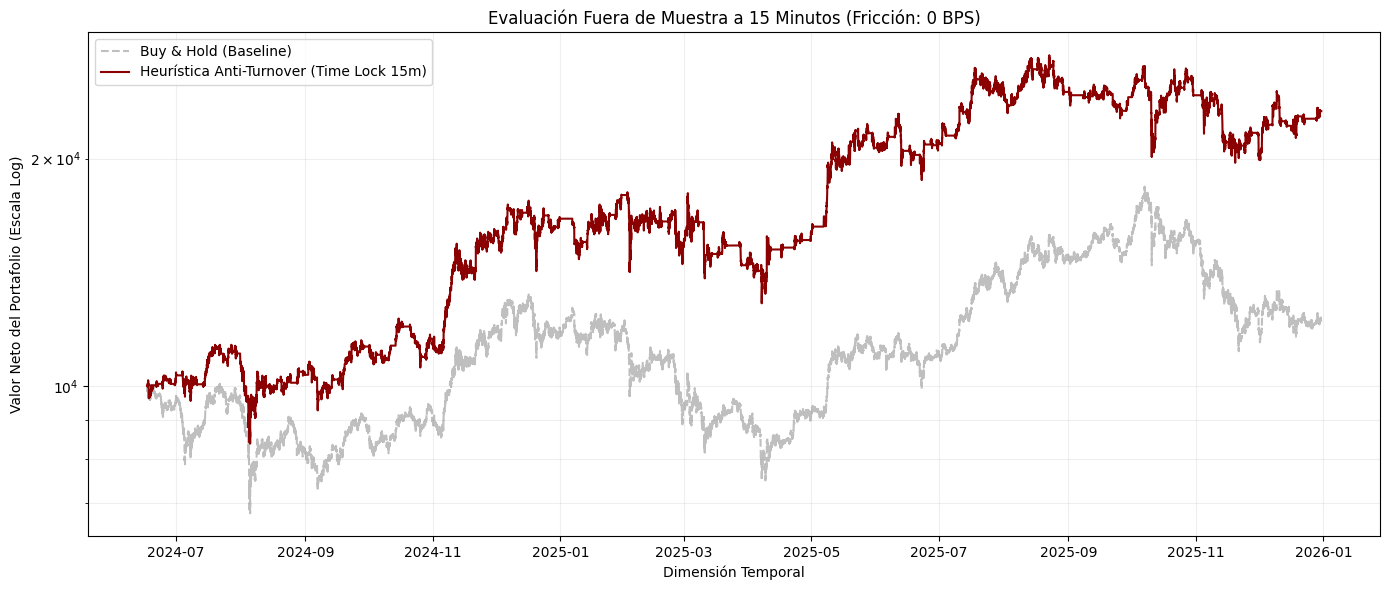

MÉTRICAS DE EJECUCIÓN FINAL
--------------------------------------------------
Total rotaciones ejecutadas:        594
Retorno Acumulado B&H:                  22.37%
Retorno Acumulado Heurística:          131.07%


In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =============================================================================
# 1. EJECUCIÓN DE LA HEURÍSTICA ADAPTADA A 15 MINUTOS
# =============================================================================

def run_anti_turnover_heuristic(env) -> tuple[pd.Series, pd.Series]:
    """
    Ejecuta la heurística anti-turnover sobre el entorno de simulación 
    utilizando las columnas indexadas a 15 minutos.
    """
    obs, _ = env.reset()
    terminated = False
    portfolio_history = [env.initial_cash]
    position_history = [0] 
    
    # USO ESTRICTO DE TUS VARIABLES: Mapeo dinámico de sufijos de horas reales
    # Reemplazamos la antigua escala macro por la de 1024h detectada en la PSD
    idx_a1_abs_1024 = env.feature_cols.index("asset_1_abs_ret_1024h")
    idx_a1_log_24   = env.feature_cols.index("asset_1_log_ret_24h")
    idx_a1_log_171  = env.feature_cols.index("asset_1_log_ret_171h")
    
    current_position = 0
    bars_in_trade = 0
    
    # CONVERSIÓN CRÍTICA: 24 horas equivalen a 96 barras de 15 minutos
    MIN_HOLD_BARS = 24 * 4  
    
    # Umbrales adaptados a la distribución de las nuevas columnas
    ENTRY_THRESHOLD = 1.5
    EXIT_THRESHOLD = 0.0
    MACRO_VOL_FILTER = 2.0
    
    while not terminated:
        vol_macro = obs[idx_a1_abs_1024]
        mom_rapido = obs[idx_a1_log_24]
        mom_lento = obs[idx_a1_log_171]
        
        if current_position == 0:
            # Entrada si la marea macro tiene volatilidad y el impulso intradiario empuja
            if vol_macro > MACRO_VOL_FILTER and mom_rapido > ENTRY_THRESHOLD:
                current_position = 1
                bars_in_trade = 0
                
        elif current_position == 1:
            bars_in_trade += 1
            # Salida solo si se cumple el Time Lock de barras y el impulso lento se agota
            if bars_in_trade >= MIN_HOLD_BARS and mom_lento < EXIT_THRESHOLD:
                current_position = 0
                bars_in_trade = 0
                
        action = 1 if current_position == 1 else 0
        obs, reward, terminated, _, info = env.step(action)
        
        portfolio_history.append(info["portfolio_value"])
        position_history.append(current_position) 
        
    # Alineación exacta de índices del DataFrame original respetando el lookback
    inicio = env._lookback - 1
    valid_index = env.data.index[inicio : inicio + len(portfolio_history)]
    
    curve = pd.Series(portfolio_history, index=valid_index)
    positions = pd.Series(position_history, index=valid_index)
    
    return curve, positions


# =============================================================================
# 2. ORQUESTADOR DE EVALUACIÓN FUERA DE MUESTRA (8 BPS)
# =============================================================================

def execute_test_evaluation(data_test: pd.DataFrame, test_features: pd.DataFrame) -> None:
    """
    Orquesta la ejecución comparativa en el conjunto fuera de muestra a 15 minutos.
    """
    if "cash" not in data_test.columns:
        data_test = data_test.copy()
        data_test["cash"] = 1.0

    # REGLA OPERATIVA: Fijamos el costo de transacción real en 8 BPS
    REAL_FEE = 0
    print(f"Inicializando entorno de evaluación (Comisión: {REAL_FEE} BPS)...")
    env = HeuristicTradingEnv(data_test, test_features, transaction_cost_bps=REAL_FEE)
    
    print("Ejecutando Baseline (Buy & Hold Equitativo)...")
    obs, _ = env.reset()
    terminated = False
    bh_history = [env.initial_cash]
    while not terminated:
        obs, reward, terminated, _, info = env.step(4)  # Acción discreta de asignación fija
        bh_history.append(info["portfolio_value"])
        
    inicio_idx = env._lookback - 1
    bh_curve = pd.Series(bh_history, index=env.data.index[inicio_idx : inicio_idx + len(bh_history)])
    
    print("Ejecutando Heurística Anti-Turnover (Filtro 15m)...")
    env.reset()
    anti_turnover_curve, posiciones_heuristica = run_anti_turnover_heuristic(env)
    
    # Cálculo exacto de rotaciones discretas basadas en cambios de estado posicional
    cambios_posicion = posiciones_heuristica.diff().fillna(0).abs()
    total_trades = int(cambios_posicion.sum())
    
    # Graficación en escala logarítmica para análisis de curvas de equidad
    plt.figure(figsize=(14, 6))
    plt.plot(bh_curve, label='Buy & Hold (Baseline)', color='gray', alpha=0.5, linestyle='--')
    plt.plot(anti_turnover_curve, label='Heurística Anti-Turnover (Time Lock 15m)', color='darkred', linewidth=1.5)
    plt.yscale('log')
    plt.title(f"Evaluación Fuera de Muestra a 15 Minutos (Fricción: {REAL_FEE} BPS)")
    plt.ylabel("Valor Neto del Portafolio (Escala Log)")
    plt.xlabel("Dimensión Temporal")
    plt.legend(loc='upper left')
    plt.grid(True, which="both", alpha=0.2)
    plt.tight_layout()
    plt.show()
    
    print("=" * 50)
    print("MÉTRICAS DE EJECUCIÓN FINAL")
    print("-" * 50)
    print(f"Total rotaciones ejecutadas:        {total_trades}")
    print(f"Retorno Acumulado B&H:               {(bh_curve.iloc[-1] / bh_curve.iloc[0] - 1) * 100:>8.2f}%")
    print(f"Retorno Acumulado Heurística:        {(anti_turnover_curve.iloc[-1] / anti_turnover_curve.iloc[0] - 1) * 100:>8.2f}%")
    print("=" * 50)

# =============================================================================
# 3. PIPELINE DE CONSTRUCCIÓN Y LANZAMIENTO
# =============================================================================
# Generamos el estado completo con el nuevo soporte de variables mapeadas
agent_state_features = build_complete_agent_state(data_test, scales_hours=[24, 171, 410, 1024])

# Ejecutamos la evaluación comparativa neta
execute_test_evaluation(data_test, agent_state_features)